# TravelTide Mastery Project

## Kundensegmentierung und Perk-Zuweisung

### Ziel des Notebooks

In diesem Notebook werden die im Rahmen der Datenaufbereitung entwickelten
Kundenmerkmale genutzt, um Kunden mit ähnlichem Reise-, Buchungs- und
Nutzungsverhalten zu identifizieren.

Hierfür werden zunächst geeignete Merkmale für die Segmentierung ausgewählt
und vorbereitet. Anschließend werden verschiedene Verfahren zur
Kundensegmentierung untersucht:

- K-Means-Clustering
- DBSCAN
- Dimensionsreduktion mit PCA

Die Ergebnisse der Verfahren werden anhand geeigneter Kennzahlen sowie ihrer
inhaltlichen Interpretierbarkeit verglichen. Auf Grundlage der finalen
Kundensegmente werden die charakteristischen Verhaltensweisen der einzelnen
Gruppen beschrieben und verständliche Segmentbezeichnungen entwickelt.

Abschließend wird jedem Kunden ein voraussichtlich passender Benefit aus dem
geplanten TravelTide-Rewards-Programm zugeordnet:

- kostenlose Hotelmahlzeit
- kostenloses Aufgabegepäck
- keine Stornierungsgebühren
- exklusive Rabatte
- kostenlose Hotelnacht bei gemeinsamer Flug- und Hotelbuchung

Das Ergebnis ist eine finale Kundentabelle, die neben den aufbereiteten
Kundenmerkmalen auch die Segmentzugehörigkeit und den empfohlenen Benefit
enthält.

## 1. Datenimport und erste Datenprüfung

Zunächst wird die in Notebook 01 erstellte finale Kundentabelle eingelesen.
Sie enthält pro Kunde genau eine Zeile sowie die aufbereiteten demografischen,
verhaltensbezogenen und monetären Merkmale.

Vor der Segmentierung werden die Dimensionen der Tabelle, die Eindeutigkeit
der Nutzer, die Datentypen sowie die vorhandenen Spalten überprüft. Dadurch
wird sichergestellt, dass die Daten vollständig und in der erwarteten
Struktur vorliegen.

In [1]:
# Bibliotheken importieren

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")

In [2]:
# Finale Kundentabelle aus der Datenaufbereitung einlesen

customer_features = pd.read_csv(
    "../data/processed/customer_features.csv"
)

print(f"Zeilen: {customer_features.shape[0]}")
print(f"Spalten: {customer_features.shape[1]}")

display(customer_features.head())

Zeilen: 5752
Spalten: 79


,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age,customer_tenure_days,customer_tenure_months,session_count,mean_session_duration_minutes,median_session_duration_minutes,total_page_clicks,mean_page_clicks,low_click_session_rate,booking_session_count,flight_booking_session_count,hotel_booking_session_count,package_booking_session_count,cancellation_count,flight_discount_offer_count,hotel_discount_offer_count,mean_flight_discount_amount,mean_hotel_discount_amount,discounted_flight_booking_count,discounted_hotel_booking_count,booking_session_rate,cancellation_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,flight_booking_count,total_flight_value_before_discount_usd,total_flight_value_after_discount_usd,total_realized_flight_spend_usd,mean_flight_booking_value_after_discount_usd,total_seats,mean_seats,total_checked_bags,mean_checked_bags,mean_fare_per_seat_after_discount_usd,return_flight_rate,cancelled_flight_count,weighted_fare_per_seat_after_discount_usd,hotel_booking_count,total_hotel_value_before_discount_usd,mean_hotel_value_before_discount_usd,total_hotel_value_after_discount_usd,mean_hotel_value_after_discount_usd,total_realized_hotel_spend_usd,mean_completed_hotel_spend_usd,total_hotel_nights,mean_hotel_nights,total_rooms,mean_rooms,mean_hotel_price_per_room_usd,median_hotel_price_per_room_usd,unique_hotel_brands,unique_hotel_cities,extended_stay_booking_count,extended_stay_booking_share,cancelled_hotel_count,preferred_hotel_segment,preferred_hotel_city,hotel_price_tier_share_Low price,hotel_price_tier_share_Medium price,hotel_price_tier_share_High price,hotel_price_tier_share_Very high price,has_flight_booking,has_hotel_booking,has_travel_booking,checked_bags_per_seat,total_cancelled_bookings,historical_customer_value_usd
0,23557,1958-12-08,F,True,False,usa,new york,LGA,40.777,-73.872,2021-07-22,64,736,24.179,8,1.277,1.158,82,10.250,0.000,2,0,2,0,0,0,2,NaN,0.175,0,1,0.250,0.000,0.000,NaN,0.500,0.000,0.000,0.000,0.000,NaN,0.000,NaN,0.000,NaN,NaN,NaN,0.000,NaN,2.000,"3,802.000","1,901.000","3,670.500","1,835.250","3,670.500","1,835.250",20.000,10.000,3.000,1.500,177.000,177.000,2.000,2.000,1.000,0.500,0.000,Economy,Calgary,0.500,0.000,0.000,0.500,False,True,True,0.000,0.000,"3,670.500"
1,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,51,536,17.608,8,1.129,0.625,73,9.125,0.000,2,2,2,2,0,0,1,NaN,0.100,0,0,0.250,0.000,1.000,NaN,0.000,2.000,864.090,864.090,864.090,432.045,3.000,1.500,1.000,0.500,276.252,1.000,0.000,288.030,2.000,230.000,115.000,230.000,115.000,230.000,115.000,2.000,1.000,3.000,1.500,90.000,90.000,2.000,2.000,0.000,0.000,0.000,Luxury,Jacksonville,0.500,0.500,0.000,0.000,True,True,True,0.333,0.000,"1,094.090"
2,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,50,526,17.280,8,2.038,2.433,131,16.375,0.000,2,1,2,1,0,2,0,0.075,NaN,0,0,0.250,0.000,0.500,0.000,NaN,1.000,189.910,189.910,189.910,189.910,1.000,1.000,0.000,0.000,189.910,1.000,0.000,189.910,2.000,"2,199.000","1,099.500","2,199.000","1,099.500","2,199.000","1,099.500",8.000,4.000,3.000,1.500,198.500,198.500,2.000,2.000,0.000,0.000,0.000,Luxury,Edmonton,0.000,0.500,0.000,0.500,True,True,True,0.000,0.000,"2,388.910"
3,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,42,526,17.280,8,1.962,2.217,126,15.750,0.125,5,5,5,5,0,2,1,0.150,0.100,1,0,0.625,0.000,1.000,0.500,0.000,5.000,"1,242.660","1,237.693","1,237.693",247.539,5.000,1.000,2.000,0.400,247.539,1.000,0.000,247.539,5.000,"2,429.000",485.800,"2,429.000",485.800,"2,429.000",485.800,19.000,3.800,5.000,1.000,136.000,132.000,5.000,5.000,1.000,0.200,0.000,Luxury,Charlotte,0.200,0.400,0.400,0.000,True,True,True,0.400,0.000,"3,666.693"
4,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,44,519,17.050,8,12.649,2.392,240,30.000,0.000,1,1,1,1,1,1,1,NaN,NaN,0,0,0.125,0.125,1.000,0.000,0.000,1.

In [3]:
# Struktur und Datentypen prüfen

customer_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 5752 entries, 0 to 5751
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   user_id                                       5752 non-null   int64  
 1   birthdate                                     5752 non-null   str    
 2   gender                                        5752 non-null   str    
 3   married                                       5752 non-null   bool   
 4   has_children                                  5752 non-null   bool   
 5   home_country                                  5752 non-null   str    
 6   home_city                                     5752 non-null   str    
 7   home_airport                                  5752 non-null   str    
 8   home_airport_lat                              5752 non-null   float64
 9   home_airport_lon                              5752 non-null   float64
 10 

In [4]:
# Anzahl eindeutiger Kunden prüfen

print(
    "Eindeutige Nutzer:",
    customer_features["user_id"].nunique()
)

print(
    "Doppelte Nutzer:",
    customer_features["user_id"].duplicated().sum()
)

Eindeutige Nutzer: 5752
Doppelte Nutzer: 0


In [5]:
# Alle vorhandenen Spalten (= Merkmale) übersichtlich anzeigen.

columns_overview = pd.DataFrame({
    "column": customer_features.columns,
    "dtype": customer_features.dtypes.astype(str).values,
    "missing_values": customer_features.isna().sum().values,
    "unique_values": customer_features.nunique(dropna=False).values
})

display(columns_overview)

,column,dtype,missing_values,unique_values
0,user_id,int64,0,5752
1,birthdate,str,0,4625
2,gender,str,0,3
3,married,bool,0,2
4,has_children,bool,0,2
5,home_country,str,0,2
6,home_city,str,0,105
7,home_airport,str,0,159
8,home_airport_lat,float64,0,158
9,home_airport_lon,float64,0,158


In [6]:
# Numerische und nicht numerische Spalten unterscheiden

numeric_columns = customer_features.select_dtypes(
    include="number"
).columns.tolist()

non_numeric_columns = customer_features.select_dtypes(
    exclude="number"
).columns.tolist()

print("Numerische Spalten:")
display(numeric_columns)

print("\nNicht numerische Spalten:")
display(non_numeric_columns)

Numerische Spalten:


['user_id',
 'home_airport_lat',
 'home_airport_lon',
 'age',
 'customer_tenure_days',
 'customer_tenure_months',
 'session_count',
 'mean_session_duration_minutes',
 'median_session_duration_minutes',
 'total_page_clicks',
 'mean_page_clicks',
 'low_click_session_rate',
 'booking_session_count',
 'flight_booking_session_count',
 'hotel_booking_session_count',
 'package_booking_session_count',
 'cancellation_count',
 'flight_discount_offer_count',
 'hotel_discount_offer_count',
 'mean_flight_discount_amount',
 'mean_hotel_discount_amount',
 'discounted_flight_booking_count',
 'discounted_hotel_booking_count',
 'booking_session_rate',
 'cancellation_session_rate',
 'package_booking_rate',
 'flight_discount_conversion_rate',
 'hotel_discount_conversion_rate',
 'flight_booking_count',
 'total_flight_value_before_discount_usd',
 'total_flight_value_after_discount_usd',
 'total_realized_flight_spend_usd',
 'mean_flight_booking_value_after_discount_usd',
 'total_seats',
 'mean_seats',
 'tota


Nicht numerische Spalten:


['birthdate',
 'gender',
 'married',
 'has_children',
 'home_country',
 'home_city',
 'home_airport',
 'sign_up_date',
 'preferred_hotel_segment',
 'preferred_hotel_city',
 'has_flight_booking',
 'has_hotel_booking',
 'has_travel_booking']

## 2. Regelbasierte Kundensegmentierung

Im ersten Schritt werden Kunden mit besonders klaren und geschäftlich
relevanten Eigenschaften regelbasiert segmentiert. Dazu werden sowohl
Verhaltensmerkmale als auch ausgewählte demografische Informationen
verwendet.

### Definition der regelbasierten Kundengruppen

Für die regelbasierte Segmentierung werden sechs Kundengruppen definiert,
die sich durch besonders klar erkennbare und geschäftlich relevante
Verhaltensweisen auszeichnen.

Die Regeln basieren auf den zuvor entwickelten Kundenmerkmalen und
kombinieren monetäre, buchungsbezogene sowie ausgewählte demografische
Informationen.

| Gruppe | Kerngedanke | Regel |
|---|---|---|
| **High-Value Bookers** | Kunden mit einem besonders hohen bisher realisierten Kundenwert | `historical_customer_value_usd` liegt innerhalb der obersten 10 % |
| **Family & Group Travelers** | Kunden, die mit mehreren Personen und Kindern reisen | Kinder vorhanden und durchschnittlich mindestens 1,8 gebuchte Sitzplätze |
| **Long-Stay Hotel Guests** | Kunden mit überdurchschnittlich langen Hotelaufenthalten | durchschnittlich mindestens 7 Hotelnächte je Buchung |
| **Discount-Responsive Travelers** | Kunden, die nachweislich häufig auf Rabattangebote reagieren | mindestens 2 Rabattangebote erhalten und mindestens 50 % davon genutzt |
| **Baggage-Intensive Flyers** | regelmäßige Flugkunden mit einer hohen Nutzung von Aufgabegepäck | mindestens 2 Flugbuchungen und durchschnittlich mindestens 0,75 Gepäckstücke je Sitzplatz |
| **Cancellation-Experienced Travelers** | Kunden mit bisheriger Stornierungserfahrung | mindestens eine stornierte Flug- oder Hotelbuchung |

Die Gruppen wurden so gewählt, dass sie anhand beobachtbarer Merkmale
nachvollziehbar, für die spätere Entwicklung von Benefits relevant und
ausreichend spezifisch sind.

Die Regeln müssen nicht gegenseitig exklusiv sein. Ein Kunde kann
beispielsweise gleichzeitig einen hohen Kundenwert besitzen, häufig
Rabattangebote nutzen und mit viel Aufgabegepäck reisen. Deshalb werden
zunächst separate Indikatoren für alle erfüllten Regeln gespeichert. 
Erst auf dieser Grundlage wird eine
Prioritätsreihenfolge für die eindeutige Segmentzuordnung festgelegt, um ein
primäres Segment vergeben.

Kunden, die keine der Regeln erfüllen, werden nicht künstlich einer Gruppe
zugeordnet. Sie werden im anschließenden Clustering datengetrieben weiter
segmentiert.

In [7]:
# Benötigte Kennzahlen vorbereiten

customer_features["total_discount_offer_count"] = (
    customer_features["flight_discount_offer_count"]
    + customer_features["hotel_discount_offer_count"]
)

customer_features["total_discounted_booking_count"] = (
    customer_features["discounted_flight_booking_count"]
    + customer_features["discounted_hotel_booking_count"]
)

customer_features["booking_discount_rate"] = np.where(
    customer_features["total_discount_offer_count"] > 0,
    (
        customer_features["total_discounted_booking_count"]
        / customer_features["total_discount_offer_count"]
    ),
    np.nan
)

In [8]:
# Grenzwert für Top Spenders berechnen.

high_value_threshold = (
    customer_features[
        "historical_customer_value_usd"
    ]
    .quantile(0.90)
)

print(
    "Grenzwert für High-Value Bookers:",
    round(high_value_threshold, 2),
    "USD"
)

Grenzwert für High-Value Bookers: 5799.32 USD


In [9]:
# Eigene Regel-Flags erstellen

rule_flags = pd.DataFrame({
    "user_id": customer_features["user_id"],

    # Oberste 10 % nach bisher realisiertem Kundenwert
    "high_value_booker": (
        customer_features["historical_customer_value_usd"]
        >= high_value_threshold
    ),

    # Kunden mit Kindern und mehreren gebuchten Sitzplätzen
    "family_group_traveler": (
        (customer_features["has_children"] == True)
        & (customer_features["mean_seats"] >= 1.80)
    ),

    # Durchschnittlich mindestens sieben Hotelnächte
    "long_stay_hotel_guest": (
        customer_features["mean_hotel_nights"] >= 7
    ),

    # Mindestens zwei Angebote erhalten und mindestens die Hälfte genutzt
    "discount_responsive_traveler": (
        (customer_features["total_discount_offer_count"] >= 2)
        & (customer_features["booking_discount_rate"] >= 0.50)
    ),

    # Wiederholte Flugbuchungen mit relativ viel Aufgabegepäck
    "baggage_intensive_flyer": (
        (customer_features["flight_booking_count"] >= 2)
        & (customer_features["checked_bags_per_seat"] >= 0.75)
    ),

    # Mindestens eine stornierte Flug- oder Hotelbuchung
    "cancellation_experienced_traveler": (
        customer_features["total_cancelled_bookings"] >= 1
    )
})

In [10]:
# Fehlende Vergleiche behandeln

rule_columns = [
    "high_value_booker",
    "family_group_traveler",
    "long_stay_hotel_guest",
    "discount_responsive_traveler",
    "baggage_intensive_flyer",
    "cancellation_experienced_traveler"
]

rule_flags[rule_columns] = (
    rule_flags[rule_columns]
    .fillna(False)
    .astype(bool)
)

In [11]:
# Gruppengrößen prüfen

rule_summary = pd.DataFrame({
    "customer_count": (
        rule_flags[rule_columns]
        .sum()
    ),
    "customer_share_percent": (
        rule_flags[rule_columns]
        .mean()
        * 100
    )
}).sort_values(
    "customer_count",
    ascending=False
)

display(rule_summary)

,customer_count,customer_share_percent
discount_responsive_traveler,1181,20.532
baggage_intensive_flyer,861,14.969
long_stay_hotel_guest,596,10.362
high_value_booker,576,10.014
cancellation_experienced_traveler,562,9.771
family_group_traveler,182,3.164


In [12]:
# Zahl erfüllter Regeln prüfen

rule_flags["matched_rule_count"] = (
    rule_flags[rule_columns]
    .sum(axis=1)
)

rule_count_summary = (
    rule_flags["matched_rule_count"]
    .value_counts()
    .sort_index()
    .rename("customer_count")
    .to_frame()
)

rule_count_summary["customer_share_percent"] = (
    rule_count_summary["customer_count"]
    / len(rule_flags)
    * 100
)

display(rule_count_summary)

,customer_count,customer_share_percent
matched_rule_count,,
0,2817,48.974
1,2083,36.213
2,702,12.204
3,131,2.277
4,17,0.296
5,2,0.035


,high_value_booker,family_group_traveler,long_stay_hotel_guest,discount_responsive_traveler,baggage_intensive_flyer,cancellation_experienced_traveler
high_value_booker,576,42,150,188,91,20
family_group_traveler,42,182,38,32,28,58
long_stay_hotel_guest,150,38,596,74,49,99
discount_responsive_traveler,188,32,74,1181,227,34
baggage_intensive_flyer,91,28,49,227,861,87
cancellation_experienced_traveler,20,58,99,34,87,562


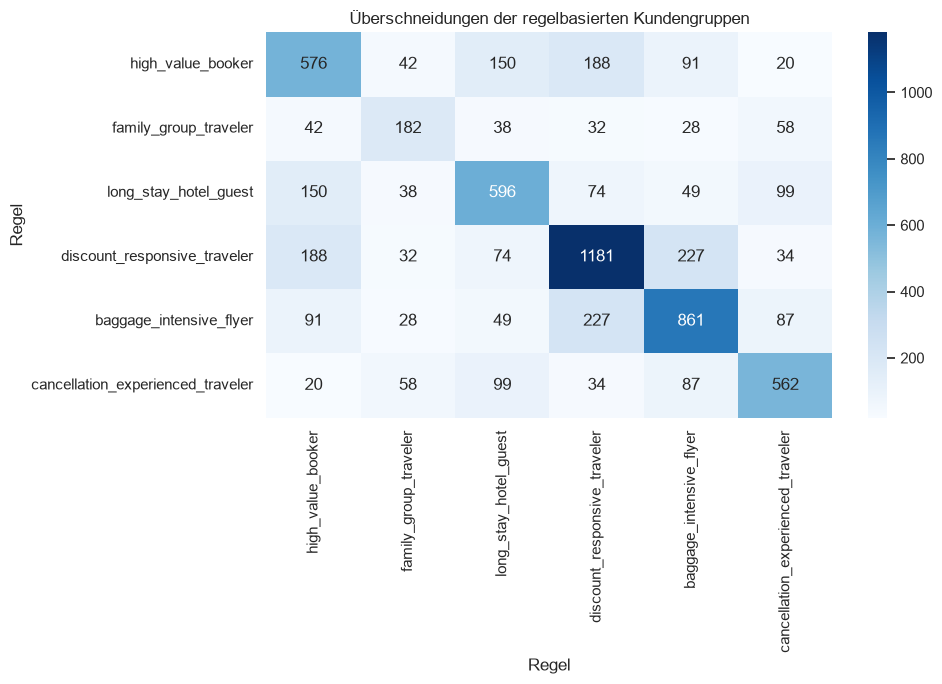

In [13]:
# Überschneidungen prüfen

overlap_matrix = (
    rule_flags[rule_columns]
    .astype(int)
    .T
    .dot(
        rule_flags[rule_columns]
        .astype(int)
    )
)

display(overlap_matrix)

plt.figure(figsize=(10, 7))

sns.heatmap(
    overlap_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Überschneidungen der regelbasierten Kundengruppen"
)

plt.xlabel("Regel")
plt.ylabel("Regel")
plt.tight_layout()
plt.show()

In [14]:
# Verbleibende Kunden bestimmen

unassigned_rule_mask = (
    rule_flags["matched_rule_count"] == 0
)

print(
    "Mindestens einer Regel zugeordnet:",
    (~unassigned_rule_mask).sum()
)

print(
    "Noch nicht zugeordnet:",
    unassigned_rule_mask.sum()
)

print(
    "Anteil noch nicht zugeordnet:",
    round(
        unassigned_rule_mask.mean() * 100,
        2
    ),
    "%"
)

Mindestens einer Regel zugeordnet: 2935
Noch nicht zugeordnet: 2817
Anteil noch nicht zugeordnet: 48.97 %


In [15]:
# Eindeutig regelbasierte Kundensegmente erstellen.

customer_segments = (
    customer_features
    .merge(
        rule_flags[
            ["user_id"]
            + rule_columns
            + ["matched_rule_count"]
        ],
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

### Priorisierung überschneidender Regeln

Da einige Kunden mehrere Regeln gleichzeitig erfüllen, wird für die finale
Segmentzuordnung eine Prioritätsreihenfolge festgelegt. Dabei werden
spezifische Reisebedürfnisse vor allgemeineren Wertmerkmalen priorisiert:

1. Family & Group Travelers
2. Long-Stay Hotel Guests
3. Baggage-Intensive Flyers
4. Discount-Responsive Travelers
5. Cancellation-Experienced Travelers
6. High-Value Bookers

Ein hoher Kundenwert wird in dieser Reihenfolge zuletzt berücksichtigt, da
er die wirtschaftliche Bedeutung eines Kunden beschreibt, aber nicht
unmittelbar dessen konkretes Reisebedürfnis. Das zusätzliche
`high_value_booker`-Flag bleibt unabhängig vom primären Segment erhalten.
Dadurch können besonders wertvolle Kunden auch innerhalb der übrigen
Reisegruppen identifiziert werden.

In [16]:
# Prioritätsreihenfolge der regelbasierten Segmente

priority_conditions = [
    customer_segments["family_group_traveler"],
    customer_segments["long_stay_hotel_guest"],
    customer_segments["baggage_intensive_flyer"],
    customer_segments["discount_responsive_traveler"],
    customer_segments["cancellation_experienced_traveler"],
    customer_segments["high_value_booker"]
]

priority_segment_names = [
    "Family & Group Travelers",
    "Long-Stay Hotel Guests",
    "Baggage-Intensive Flyers",
    "Discount-Responsive Travelers",
    "Cancellation-Experienced Travelers",
    "High-Value Bookers"
]


# Eindeutiges primäres Segment vergeben

customer_segments["rule_based_segment"] = np.select(
    priority_conditions,
    priority_segment_names,
    default="Unassigned"
)

In [17]:
# Finale Größen nach Priorisierung prüfen

rule_based_segment_summary = (
    customer_segments[
        "rule_based_segment"
    ]
    .value_counts()
    .rename("customer_count")
    .to_frame()
)

rule_based_segment_summary[
    "customer_share_percent"
] = (
    rule_based_segment_summary[
        "customer_count"
    ]
    / len(customer_segments)
    * 100
)

display(rule_based_segment_summary)

,customer_count,customer_share_percent
rule_based_segment,,
Unassigned,2817,48.974
Discount-Responsive Travelers,868,15.090
Baggage-Intensive Flyers,789,13.717
Long-Stay Hotel Guests,558,9.701
Cancellation-Experienced Travelers,330,5.737
High-Value Bookers,208,3.616
Family & Group Travelers,182,3.164


In [18]:
# Prüfen, welche Mehrfachmerkmale erhalten bleiben

high_value_by_segment = (
    customer_segments
    .groupby(
        "rule_based_segment",
        observed=True
    )
    .agg(
        customer_count=(
            "user_id",
            "count"
        ),
        high_value_customer_count=(
            "high_value_booker",
            "sum"
        ),
        high_value_customer_share=(
            "high_value_booker",
            "mean"
        )
    )
    .sort_values(
        "customer_count",
        ascending=False
    )
)

high_value_by_segment[
    "high_value_customer_share"
] *= 100

display(high_value_by_segment)

,customer_count,high_value_customer_count,high_value_customer_share
rule_based_segment,,,
Unassigned,2817,0,0.000
Discount-Responsive Travelers,868,118,13.594
Baggage-Intensive Flyers,789,62,7.858
Long-Stay Hotel Guests,558,140,25.090
Cancellation-Experienced Travelers,330,6,1.818
High-Value Bookers,208,208,100.000
Family & Group Travelers,182,42,23.077


In [19]:
# Noch nicht zugeordnete Kunden für das Clustering erstellen

unassigned_customers = (
    customer_segments[
        customer_segments[
            "rule_based_segment"
        ] == "Unassigned"
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Kunden für das anschließende Clustering:",
    len(unassigned_customers)
)

print(
    "Eindeutige Nutzer:",
    unassigned_customers["user_id"].nunique()
)

Kunden für das anschließende Clustering: 2817
Eindeutige Nutzer: 2817


### Ergebnis der regelbasierten Segmentierung

Durch die regelbasierte Segmentierung konnten 2.935 Kunden beziehungsweise
rund 51 % der Kohorte einem primären Segment zugeordnet werden.

Das größte regelbasierte Segment bilden die Discount-Responsive Travelers
mit 868 Kunden, gefolgt von den Baggage-Intensive Flyers mit 789 Kunden und
den Long-Stay Hotel Guests mit 558 Kunden. Weitere Kunden wurden als
Cancellation-Experienced Travelers, High-Value Bookers oder Family & Group
Travelers klassifiziert.

Von den insgesamt 576 High-Value-Kunden wurden 208 primär dem Segment
High-Value Bookers zugeordnet. Die übrigen erfüllen spezifischere
Verhaltensregeln und wurden deshalb vorrangig entsprechenden Reisegruppen
zugeordnet. Ihr High-Value-Status bleibt durch ein separates Merkmal
erhalten.

Die verbleibenden 2.817 Kunden beziehungsweise rund 49 % der Kohorte
erfüllen keine der festgelegten Regeln. Für diese Kunden wird im nächsten
Schritt eine datengetriebene Segmentierung mit Clustering-Verfahren
durchgeführt.

## 3. Merkmalsauswahl für das Clustering

Die regelbasierte Segmentierung hat Kunden mit besonders deutlich
ausgeprägten Verhaltensweisen bereits identifiziert. Die verbleibenden
Kunden erfüllen keine der festgelegten Regeln und werden im nächsten Schritt
datengetrieben segmentiert.

Da sich Zusammensetzung und Werteverteilungen dieser Teilgruppe von der
gesamten Kohorte unterscheiden, werden die Clustering-Merkmale erneut
geprüft. Merkmale ohne verbleibende Varianz sowie stark redundante
Variablen sollen nicht in die Distanzberechnung einfließen.

Demografische Merkmale werden weiterhin nicht zur Berechnung der Cluster
verwendet. Sie werden später zur Beschreibung und Interpretation der
entstandenen Kundengruppen herangezogen.

In [20]:
# Nicht zugeordnete Kunden kontrollieren

print(
    "Zeilen:",
    len(unassigned_customers)
)

print(
    "Eindeutige Nutzer:",
    unassigned_customers["user_id"].nunique()
)

print(
    "Doppelte Nutzer:",
    unassigned_customers["user_id"].duplicated().sum()
)

Zeilen: 2817
Eindeutige Nutzer: 2817
Doppelte Nutzer: 0


In [21]:
# Flug- und Hotelorientierung neu berechnen.

total_travel_bookings_unassigned = (
    unassigned_customers["flight_booking_count"]
    + unassigned_customers["hotel_booking_count"]
)

unassigned_customers["travel_product_balance"] = np.where(
    total_travel_bookings_unassigned > 0,
    (
        unassigned_customers["flight_booking_count"]
        - unassigned_customers["hotel_booking_count"]
    )
    / total_travel_bookings_unassigned,
    0
)

In [22]:
# Vorauswahl potenzieller Clustering-Merkmale

clustering_feature_candidates = [
    # Allgemeines Buchungsverhalten
    "booking_session_rate",
    "package_booking_rate",

    # Reaktion auf Rabatte
    "flight_discount_conversion_rate",
    "hotel_discount_conversion_rate",

    # Flug- oder Hotelorientierung
    "travel_product_balance",

    # Flugverhalten
    "mean_seats",
    "checked_bags_per_seat",
    "return_flight_rate",
    "weighted_fare_per_seat_after_discount_usd",

    # Hotelverhalten
    "mean_hotel_nights",
    "median_hotel_price_per_room_usd",
    "extended_stay_booking_share",

    # Historischer Kundenwert
    "historical_customer_value_usd"
]

print(
    "Anzahl der Kandidaten:",
    len(clustering_feature_candidates)
)

Anzahl der Kandidaten: 13


In [23]:
# Verfügbarkeit der Spalten prüfen

missing_candidate_columns = [
    column
    for column in clustering_feature_candidates
    if column not in unassigned_customers.columns
]

print(
    "Nicht gefundene Merkmale:",
    missing_candidate_columns
)

Nicht gefundene Merkmale: []


In [24]:
# Arbeitstabelle für die weitere Merkmalsprüfung erstellen

cluster_user_ids = (
    unassigned_customers["user_id"]
    .copy()
)

x_candidates = (
    unassigned_customers[
        clustering_feature_candidates
    ]
    .copy()
)

print(
    "Dimensionen:",
    x_candidates.shape
)

display(x_candidates.head())

Dimensionen: (2817, 13)


,booking_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,travel_product_balance,mean_seats,checked_bags_per_seat,return_flight_rate,weighted_fare_per_seat_after_discount_usd,mean_hotel_nights,median_hotel_price_per_room_usd,extended_stay_booking_share,historical_customer_value_usd
0,0.250,1.000,NaN,0.000,0.000,1.500,0.333,1.000,288.030,1.000,90.000,0.000,"1,094.090"
1,0.250,0.500,0.000,NaN,-0.333,1.000,0.000,1.000,189.910,4.000,198.500,0.000,"2,388.910"
2,0.625,1.000,0.500,0.000,0.000,1.000,0.400,1.000,247.539,3.800,132.000,0.200,"3,666.693"
3,0.125,0.000,NaN,0.000,1.000,1.000,0.000,1.000,423.510,NaN,NaN,0.000,423.510
4,0.125,1.000,0.000,0.000,0.000,1.000,2.000,1.000,367.830,2.000,213.000,0.000,793.830


In [25]:
# Varianz und fehlende Werte prüfen.

candidate_overview = (
    x_candidates
    .describe()
    .T
)

candidate_overview["missing_values"] = (
    x_candidates
    .isna()
    .sum()
)

candidate_overview["missing_share"] = (
    candidate_overview["missing_values"]
    / len(x_candidates)
)

candidate_overview["unique_values"] = (
    x_candidates
    .nunique(dropna=False)
)

candidate_overview["variance"] = (
    x_candidates
    .var()
)

display(candidate_overview)

,count,mean,std,min,25%,50%,75%,max,missing_values,missing_share,unique_values,variance
booking_session_rate,"2,817.000",0.272,0.179,0.000,0.125,0.250,0.375,0.875,0,0.000,21,0.032
package_booking_rate,"2,427.000",0.746,0.320,0.000,0.500,1.000,1.000,1.000,390,0.138,15,0.103
flight_discount_conversion_rate,"2,138.000",0.120,0.266,0.000,0.000,0.000,0.000,1.000,679,0.241,10,0.071
hotel_discount_conversion_rate,"1,783.000",0.150,0.305,0.000,0.000,0.000,0.000,1.000,1034,0.367,9,0.093
travel_product_balance,"2,817.000",-0.027,0.307,-1.000,0.000,0.000,0.000,1.000,0,0.000,23,0.094
mean_seats,"2,299.000",1.145,0.308,1.000,1.000,1.000,1.200,4.000,518,0.184,19,0.095
checked_bags_per_seat,"2,817.000",0.339,0.388,0.000,0.000,0.333,0.500,3.000,0,0.000,21,0.151
return_flight_rate,"2,299.000",0.953,0.159,0.000,1.000,1.000,1.000,1.000,518,0.184,10,0.025
weighted_fare_per_seat_after_discount_usd,"2,299.000",360.740,208.631,13.680,232.377,334.279,451.036,"2,569.930",518,0.184,2288,"43,526.879"
mean_hotel_nights,"2,354.000",2.927,1.474,1.000,2.000,2.667,4.000,6.800,463,0.164,59,2.173


In [26]:
# Merkmale mit höchstens einem unterschiedlichen nicht fehlenden Wert anzeigen.
 
constant_features = [
    column
    for column in x_candidates.columns
    if x_candidates[column].nunique(dropna=True) <= 1
]

print(
    "Konstante Merkmale:",
    constant_features
)

Konstante Merkmale: []


In [27]:
# Fehlende Werte anzeigen
 
missing_overview = (
    x_candidates
    .isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={
        "sum": "missing_values",
        "mean": "missing_share"
    })
    .sort_values(
        "missing_values",
        ascending=False
    )
)

display(missing_overview)

,missing_values,missing_share
hotel_discount_conversion_rate,"1,034.000",0.367
flight_discount_conversion_rate,679.000,0.241
weighted_fare_per_seat_after_discount_usd,518.000,0.184
return_flight_rate,518.000,0.184
mean_seats,518.000,0.184
median_hotel_price_per_room_usd,463.000,0.164
mean_hotel_nights,463.000,0.164
package_booking_rate,390.000,0.138
booking_session_rate,0.000,0.000
travel_product_balance,0.000,0.000


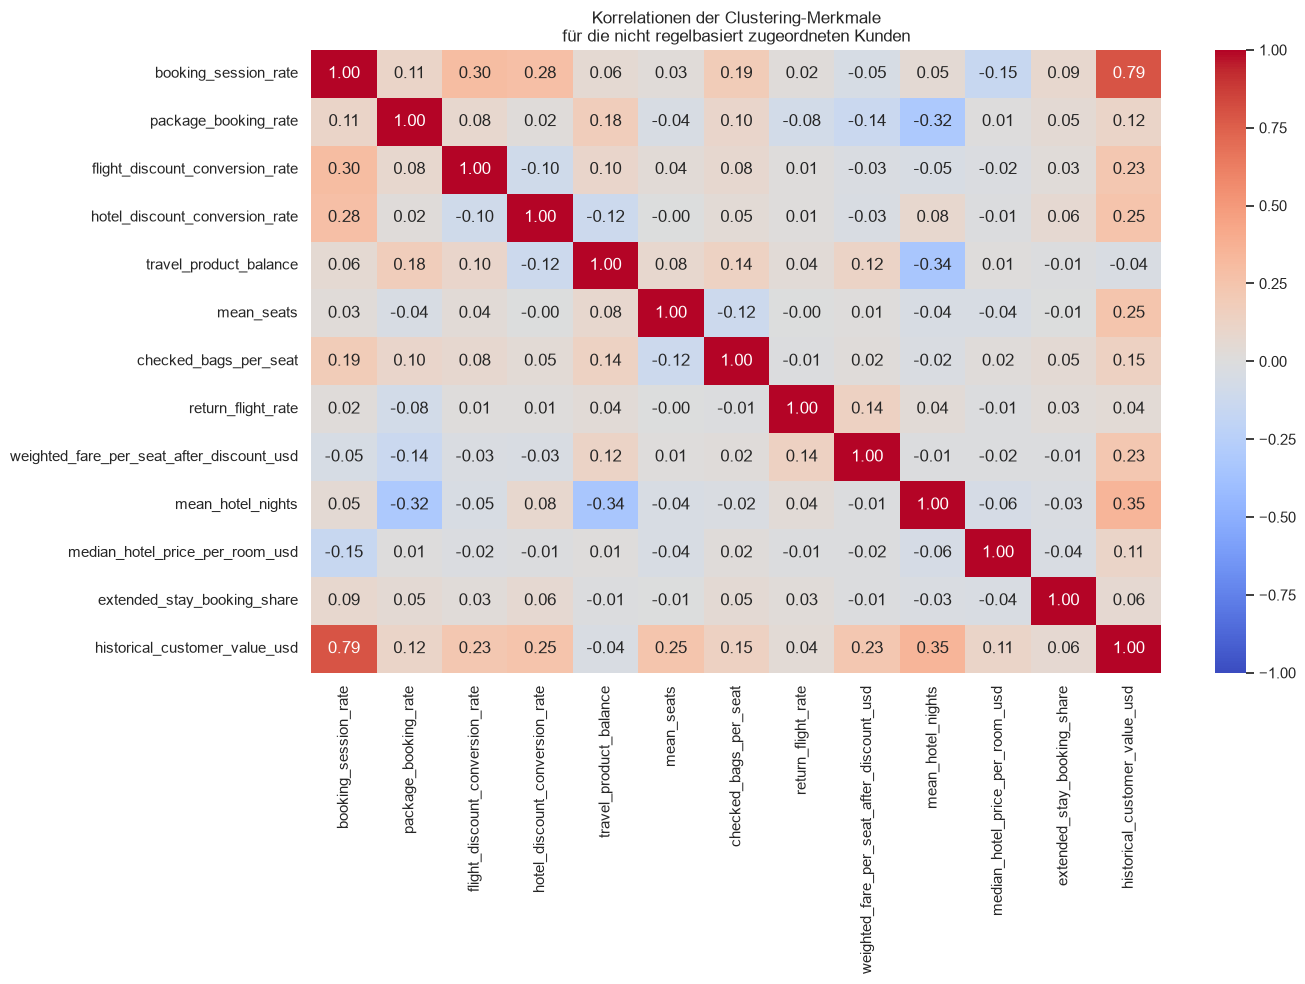

In [28]:
# Korrelation der Merkmale untersuchen

correlation_matrix_unassigned = (
    x_candidates
    .corr()
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix_unassigned,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Korrelationen der Clustering-Merkmale\n"
    "für die nicht regelbasiert zugeordneten Kunden"
)

plt.tight_layout()
plt.show()

In [29]:
# Stark korrelierte Merkmalspaare identifizieren

upper_triangle = (
    correlation_matrix_unassigned
    .where(
        np.triu(
            np.ones(
                correlation_matrix_unassigned.shape
            ),
            k=1
        ).astype(bool)
    )
)

strong_correlations_unassigned = (
    upper_triangle
    .stack()
    .reset_index()
)

strong_correlations_unassigned.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

strong_correlations_unassigned[
    "absolute_correlation"
] = (
    strong_correlations_unassigned[
        "correlation"
    ]
    .abs()
)

strong_correlations_unassigned = (
    strong_correlations_unassigned[
        strong_correlations_unassigned[
            "absolute_correlation"
        ] >= 0.70
    ]
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
)

display(strong_correlations_unassigned)

,feature_1,feature_2,correlation,absolute_correlation
12,booking_session_rate,historical_customer_value_usd,0.793,0.793


In [30]:
# Finale Merkmalsauswahl

final_clustering_features = [
    # Allgemeines Buchungsverhalten
    "booking_session_rate",
    "package_booking_rate",

    # Reaktion auf Rabatte
    "flight_discount_conversion_rate",
    "hotel_discount_conversion_rate",

    # Flug- oder Hotelorientierung
    "travel_product_balance",

    # Flugverhalten
    "mean_seats",
    "checked_bags_per_seat",
    "return_flight_rate",
    "weighted_fare_per_seat_after_discount_usd",

    # Hotelverhalten
    "mean_hotel_nights",
    "median_hotel_price_per_room_usd",
    "extended_stay_booking_share"
]

print(
    "Anzahl finaler Clustering-Merkmale:",
    len(final_clustering_features)
)

Anzahl finaler Clustering-Merkmale: 12


### Ergebnis der Merkmalsauswahl

Für die 2.817 noch nicht regelbasiert zugeordneten Kunden wurden die
potenziellen Clustering-Merkmale erneut geprüft. Kein Merkmal weist in
dieser Teilgruppe eine konstante Ausprägung auf.

Zwischen der Buchungsrate und dem historischen Kundenwert besteht mit rund
0,79 ein starker positiver Zusammenhang. Da die High-Value-Kunden bereits
regelbasiert identifiziert wurden und die Buchungsaktivität sowie das
typische Preisniveau durch andere Merkmale abgebildet werden, wird der
historische Kundenwert nicht für die Berechnung der Cluster verwendet. Er
bleibt jedoch für die spätere Beschreibung der entstandenen Segmente
erhalten.

Die übrigen Merkmale weisen keine problematisch hohen Korrelationen auf.
Die finale Auswahl umfasst zwölf Variablen zum Buchungsverhalten, zur
Rabattnutzung, zur Flug- und Hotelorientierung sowie zu den jeweiligen
Reisepräferenzen.

## 4. Datenvorbereitung für das Clustering

Die zwölf ausgewählten Merkmale werden nun speziell für die 2.817 noch
nicht regelbasiert zugeordneten Kunden vorbereitet.

Da sich die Zusammensetzung dieser Teilgruppe von der gesamten Kohorte
unterscheidet, werden Imputationswerte, Transformationen und
Skalierungsparameter ausschließlich auf Basis dieser Kunden berechnet.
Dadurch beeinflussen die bereits regelbasiert entfernten Extremgruppen die
anschließende datengetriebene Segmentierung nicht.

In [31]:
# Arbeitstabelle erstellen

cluster_user_ids = (
    unassigned_customers["user_id"]
    .copy()
)

x_cluster = (
    unassigned_customers[
        final_clustering_features
    ]
    .copy()
)

print(
    "Dimensionen der Merkmalstabelle:",
    x_cluster.shape
)

Dimensionen der Merkmalstabelle: (2817, 12)


In [32]:
# Fehlende Raten mit 0 auffüllen

zero_imputation_columns = [
    "package_booking_rate",
    "flight_discount_conversion_rate",
    "hotel_discount_conversion_rate"
]

x_cluster[zero_imputation_columns] = (
    x_cluster[zero_imputation_columns]
    .fillna(0)
)

In [33]:
# Nicht definierbare Produktmerkmale mit Median imputieren

median_imputation_columns = [
    "mean_seats",
    "return_flight_rate",
    "weighted_fare_per_seat_after_discount_usd",
    "mean_hotel_nights",
    "median_hotel_price_per_room_usd"
]

imputation_values = {}


for column in median_imputation_columns:
    column_median = (
        unassigned_customers[column]
        .median()
    )

    imputation_values[column] = column_median

    x_cluster[column] = (
        x_cluster[column]
        .fillna(column_median)
    )


display(
    pd.Series(
        imputation_values,
        name="imputation_values"
    )
)

mean_seats                                    1.000
return_flight_rate                            1.000
weighted_fare_per_seat_after_discount_usd   334.279
mean_hotel_nights                             2.667
median_hotel_price_per_room_usd             147.000
Name: imputation_values, dtype: float64

In [34]:
# Imputation kontrollieren.

print(
    "Fehlende Werte insgesamt:",
    x_cluster.isna().sum().sum()
)

print(
    "Unendliche Werte insgesamt:",
    np.isinf(x_cluster).sum().sum()
)

display(
    x_cluster.describe().T
)

Fehlende Werte insgesamt: 0
Unendliche Werte insgesamt: 0


,count,mean,std,min,25%,50%,75%,max
booking_session_rate,"2,817.000",0.272,0.179,0.000,0.125,0.250,0.375,0.875
package_booking_rate,"2,817.000",0.642,0.393,0.000,0.333,0.750,1.000,1.000
flight_discount_conversion_rate,"2,817.000",0.091,0.238,0.000,0.000,0.000,0.000,1.000
hotel_discount_conversion_rate,"2,817.000",0.095,0.253,0.000,0.000,0.000,0.000,1.000
travel_product_balance,"2,817.000",-0.027,0.307,-1.000,0.000,0.000,0.000,1.000
mean_seats,"2,817.000",1.119,0.284,1.000,1.000,1.000,1.000,4.000
checked_bags_per_seat,"2,817.000",0.339,0.388,0.000,0.000,0.333,0.500,3.000
return_flight_rate,"2,817.000",0.962,0.145,0.000,1.000,1.000,1.000,1.000
weighted_fare_per_seat_after_discount_usd,"2,817.000",355.874,188.747,13.680,258.756,334.279,417.860,"2,569.930"
mean_hotel_nights,"2,817.000",2.884,1.351,1.000,2.000,2.667,3.667,6.800


In [35]:
# Schiefe der Merkmale prüfen.

skewness_unassigned = (
    x_cluster
    .skew()
    .sort_values(
        key=abs,
        ascending=False
    )
    .to_frame("skewness")
)

display(skewness_unassigned)

,skewness
return_flight_rate,-4.667
extended_stay_booking_share,4.230
mean_seats,3.503
weighted_fare_per_seat_after_discount_usd,3.297
flight_discount_conversion_rate,2.841
hotel_discount_conversion_rate,2.725
median_hotel_price_per_room_usd,2.502
checked_bags_per_seat,1.801
mean_hotel_nights,0.783
package_booking_rate,-0.644


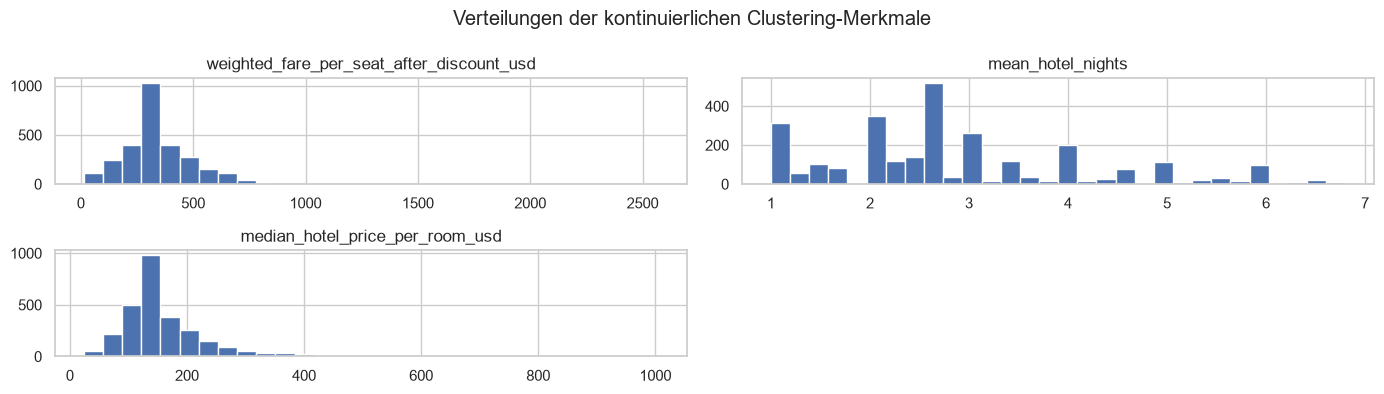

In [36]:
# Kontinuierliche Merkmale visualisieren.

continuous_features = [
    "weighted_fare_per_seat_after_discount_usd",
    "mean_hotel_nights",
    "median_hotel_price_per_room_usd"
]

x_cluster[
    continuous_features
].hist(
    bins=30,
    figsize=(14, 4)
)

plt.suptitle(
    "Verteilungen der kontinuierlichen Clustering-Merkmale"
)

plt.tight_layout()
plt.show()

In [37]:
# Stark rechtsschiefe Preismerkmale logarithmieren

x_cluster_transformed = x_cluster.copy()

log_transform_columns = [
    "weighted_fare_per_seat_after_discount_usd",
    "median_hotel_price_per_room_usd"
]

x_cluster_transformed[log_transform_columns] = (
    np.log1p(
        x_cluster_transformed[log_transform_columns]
    )
)

In [38]:
# Schiefe vor und nach der Transformation vergleichen

skewness_before_transformation = (
    x_cluster
    .skew()
    .rename("skewness_before")
)

skewness_after_transformation = (
    x_cluster_transformed
    .skew()
    .rename("skewness_after")
)

skewness_comparison_unassigned = pd.concat(
    [
        skewness_before_transformation,
        skewness_after_transformation
    ],
    axis=1
)

display(
    skewness_comparison_unassigned.loc[
        log_transform_columns
    ]
)

,skewness_before,skewness_after
weighted_fare_per_seat_after_discount_usd,3.297,-0.982
median_hotel_price_per_room_usd,2.502,0.080


In [40]:
# Skalierung der zwölf Merkmale.

from sklearn.preprocessing import StandardScaler

scaler_unassigned = StandardScaler()

x_cluster_scaled_array = scaler_unassigned.fit_transform(
    x_cluster_transformed
)

x_cluster_scaled = pd.DataFrame(
    x_cluster_scaled_array,
    columns=x_cluster_transformed.columns,
    index=x_cluster_transformed.index
)

In [41]:
# Form und fehlende beziehungsweise unendliche Werte prüfen

print("Form der skalierten Daten:", x_cluster_scaled.shape)
print(
    "Fehlende Werte:",
    x_cluster_scaled.isna().sum().sum()
)
print(
    "Unendliche Werte:",
    np.isinf(x_cluster_scaled.to_numpy()).sum()
)


# Mittelwerte und Standardabweichungen kontrollieren

scaling_check_unassigned = pd.DataFrame({
    "mean": x_cluster_scaled.mean(),
    "std": x_cluster_scaled.std(ddof=0)
})

display(scaling_check_unassigned)

Form der skalierten Daten: (2817, 12)
Fehlende Werte: 0
Unendliche Werte: 0


,mean,std
booking_session_rate,-0.000,1.000
package_booking_rate,0.000,1.000
flight_discount_conversion_rate,0.000,1.000
hotel_discount_conversion_rate,0.000,1.000
travel_product_balance,-0.000,1.000
mean_seats,-0.000,1.000
checked_bags_per_seat,-0.000,1.000
return_flight_rate,-0.000,1.000
weighted_fare_per_seat_after_discount_usd,0.000,1.000
mean_hotel_nights,-0.000,1.000


### Ergebnis der Datenvorbereitung

Für die produktbezogenen Merkmale wurden fehlende Werte abhängig von ihrer
inhaltlichen Bedeutung behandelt. Fehlende Buchungs- und Rabattquoten wurden
mit null ersetzt, wenn das betreffende Verhalten nicht beobachtet wurde.
Fehlende typische Flug- und Hotelwerte wurden dagegen mit dem Median der
nicht regelbasiert zugeordneten Kunden imputiert.

Die Verteilungen der Flugpreise pro Sitzplatz und der Hotelpreise pro Zimmer
waren deutlich rechtsschief. Beide Merkmale wurden daher mit `log1p`
transformiert. Die durchschnittliche Anzahl der Hotelnächte zeigte nur eine
moderate Schiefe und wurde nicht transformiert.

Anteile, Raten und diskrete Merkmale wurden trotz teilweise hoher Schiefe in
ihrer ursprünglichen Form beibehalten, da ihre Verteilungen überwiegend durch
inhaltlich sinnvolle Häufungen an den Wertebereichsgrenzen geprägt sind.

Abschließend wurden alle Clustering-Merkmale standardisiert. Damit besitzen
sie für die distanzbasierten Clustering-Verfahren eine vergleichbare
Größenordnung. Der vorbereitete Datensatz umfasst 2.817 bislang nicht
regelbasiert zugeordnete Kunden und zwölf Clustering-Merkmale.

## 5. K-Means-Clustering der nicht zugeordneten Kunden

Nach der regelbasierten Segmentierung konnten 2.817 Kunden keiner der
vordefinierten Gruppen eindeutig zugeordnet werden. Für diese Kunden wird
nun K-Means eingesetzt, um zusätzliche Verhaltensmuster datenbasiert zu
identifizieren.

Das Clustering basiert auf den zuvor ausgewählten, imputierten,
transformierten und standardisierten Merkmalen. Demografische Merkmale,
der historische Kundenwert und die bereits vergebenen regelbasierten
Segmente fließen nicht in die Clusterbildung ein. Sie können später zur
Beschreibung und Interpretation der gefundenen Gruppen herangezogen werden.

Zunächst werden verschiedene Clusteranzahlen verglichen. Berücksichtigt
werden dabei die Elbow-Methode, der Silhouette Score und die Größenverteilung
der entstehenden Cluster. Die finale Clusteranzahl wird anschließend sowohl
anhand der statistischen Ergebnisse als auch anhand der inhaltlichen
Interpretierbarkeit ausgewählt.

In [42]:
# Verschiedene Clusteranzahlen testen

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Zu untersuchende Clusteranzahlen

k_values = range(2, 11)

kmeans_results = []


for k in k_values:
    
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    cluster_labels = kmeans_model.fit_predict(
        x_cluster_scaled
    )
    
    cluster_sizes = pd.Series(cluster_labels).value_counts()
    
    kmeans_results.append({
        "k": k,
        "inertia": kmeans_model.inertia_,
        "silhouette_score": silhouette_score(
            x_cluster_scaled,
            cluster_labels
        ),
        "smallest_cluster_size": cluster_sizes.min(),
        "smallest_cluster_share": cluster_sizes.min() / len(cluster_labels),
        "largest_cluster_size": cluster_sizes.max(),
        "largest_cluster_share": cluster_sizes.max() / len(cluster_labels)
    })


kmeans_evaluation = pd.DataFrame(kmeans_results)

display(kmeans_evaluation)

,k,inertia,silhouette_score,smallest_cluster_size,smallest_cluster_share,largest_cluster_size,largest_cluster_share
0,2,"29,646.314",0.155,645,0.229,2172,0.771
1,3,"27,333.176",0.174,331,0.118,1877,0.666
2,4,"25,231.366",0.193,263,0.093,1617,0.574
3,5,"23,241.876",0.209,155,0.055,1489,0.529
4,6,"21,453.938",0.221,143,0.051,1357,0.482
5,7,"20,068.621",0.233,133,0.047,1208,0.429
6,8,"18,722.300",0.240,101,0.036,1165,0.414
7,9,"17,519.840",0.241,100,0.035,812,0.288
8,10,"16,638.292",0.242,90,0.032,664,0.236


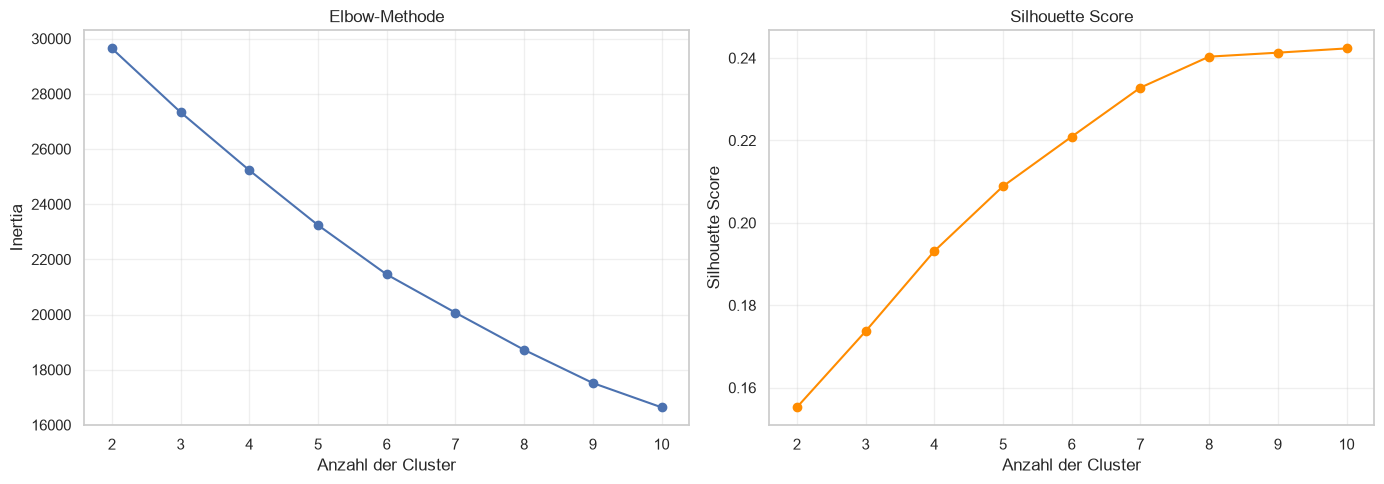

In [43]:
# Elbow-Kurve und Silhouette Score visualisieren

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    kmeans_evaluation["k"],
    kmeans_evaluation["inertia"],
    marker="o"
)

axes[0].set_title("Elbow-Methode")
axes[0].set_xlabel("Anzahl der Cluster")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(k_values))
axes[0].grid(alpha=0.3)

axes[1].plot(
    kmeans_evaluation["k"],
    kmeans_evaluation["silhouette_score"],
    marker="o",
    color="darkorange"
)

axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Anzahl der Cluster")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(k_values))
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

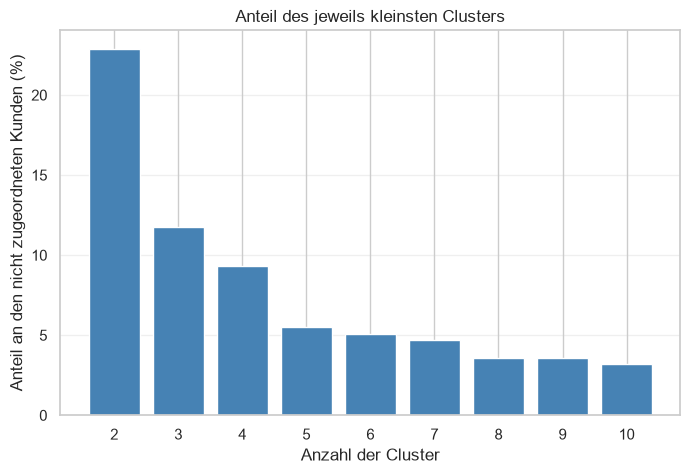

In [44]:
# Größen der jeweils kleinsten Cluster visualisieren

plt.figure(figsize=(8, 5))

plt.bar(
    kmeans_evaluation["k"].astype(str),
    kmeans_evaluation["smallest_cluster_share"] * 100,
    color="steelblue"
)

plt.title("Anteil des jeweils kleinsten Clusters")
plt.xlabel("Anzahl der Cluster")
plt.ylabel("Anteil an den nicht zugeordneten Kunden (%)")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
# Festlegung der Kandidaten für die finale Clusteranzahl.

candidate_k_values = [4, 5, 6, 7, 8, 9]

In [ ]:
# Vollständige Clustergrößen vergleichen.

candidate_cluster_sizes = []

candidate_labels = {}


for k in candidate_k_values:
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = model.fit_predict(x_cluster_scaled)
    
    candidate_labels[k] = labels
    
    size_table = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="customer_count")
    )
    
    size_table["customer_share"] = (
        size_table["customer_count"] / len(labels)
    )
    
    size_table.insert(0, "k", k)
    
    candidate_cluster_sizes.append(size_table)


candidate_cluster_sizes = pd.concat(
    candidate_cluster_sizes,
    ignore_index=True
)

display(candidate_cluster_sizes)

,k,cluster,customer_count,customer_share
0,4,0,263,0.093
1,4,1,607,0.215
2,4,2,330,0.117
3,4,3,1617,0.574
4,5,0,313,0.111
5,5,1,1489,0.529
6,5,2,253,0.090
7,5,3,607,0.215
8,5,4,155,0.055
9,6,0,301,0.107


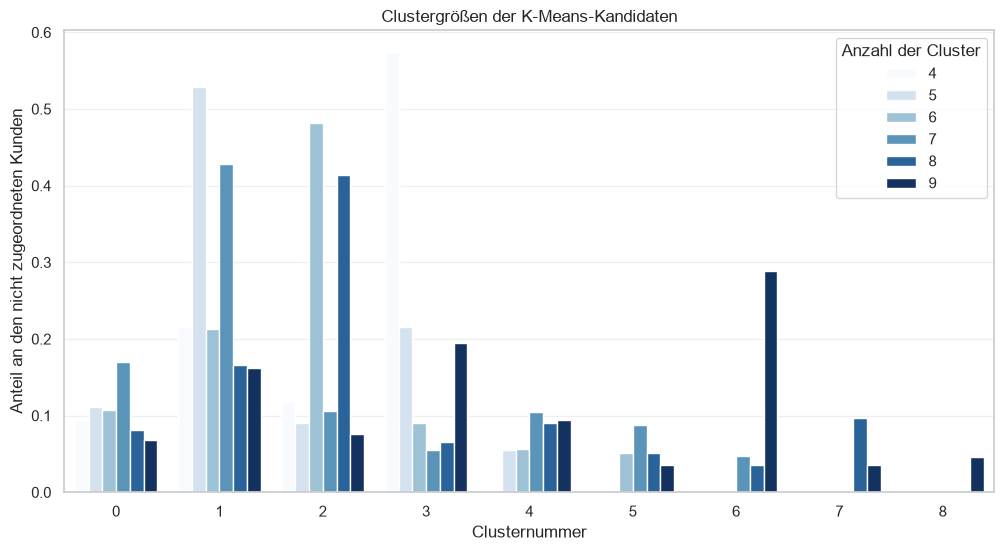

In [ ]:
# Clustergrößen visualisieren

plt.figure(figsize=(12, 6))

sns.barplot(
    data=candidate_cluster_sizes,
    x="cluster",
    y="customer_share",
    hue="k",
    palette="Blues"
)

plt.title("Clustergrößen der K-Means-Kandidaten")
plt.xlabel("Clusternummer")
plt.ylabel("Anteil an den nicht zugeordneten Kunden")
plt.legend(title="Anzahl der Cluster")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
# Stabilität der Kandidaten untersuchen.

from sklearn.metrics import adjusted_rand_score


random_states = [
    0, 1, 2, 3, 4,
    10, 20, 30, 40, 42
]

stability_results = []


for k in candidate_k_values:
    
    reference_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    reference_labels = reference_model.fit_predict(
        x_cluster_scaled
    )
    
    ari_scores = []
    
    for random_state in random_states:
        
        comparison_model = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=20
        )
        
        comparison_labels = comparison_model.fit_predict(
            x_cluster_scaled
        )
        
        ari_scores.append(
            adjusted_rand_score(
                reference_labels,
                comparison_labels
            )
        )
    
    stability_results.append({
        "k": k,
        "mean_ari": np.mean(ari_scores),
        "minimum_ari": np.min(ari_scores),
        "maximum_ari": np.max(ari_scores),
        "std_ari": np.std(ari_scores)
    })


kmeans_stability = pd.DataFrame(stability_results)

display(kmeans_stability)

,k,mean_ari,minimum_ari,maximum_ari,std_ari
0,4,0.975,0.857,1.000,0.044
1,5,0.916,0.789,1.000,0.099
2,6,0.947,0.741,1.000,0.103
3,7,0.704,0.592,1.000,0.131
4,8,0.910,0.549,1.000,0.127
5,9,0.991,0.935,1.000,0.019


In [ ]:
# Standardisierte Clusterprofile vorbereiten.

candidate_cluster_profiles = {}


for k in candidate_k_values:
    
    profile_data = x_cluster_scaled.copy()
    profile_data["cluster"] = candidate_labels[k]
    
    candidate_cluster_profiles[k] = (
        profile_data
        .groupby("cluster")
        .mean()
    )

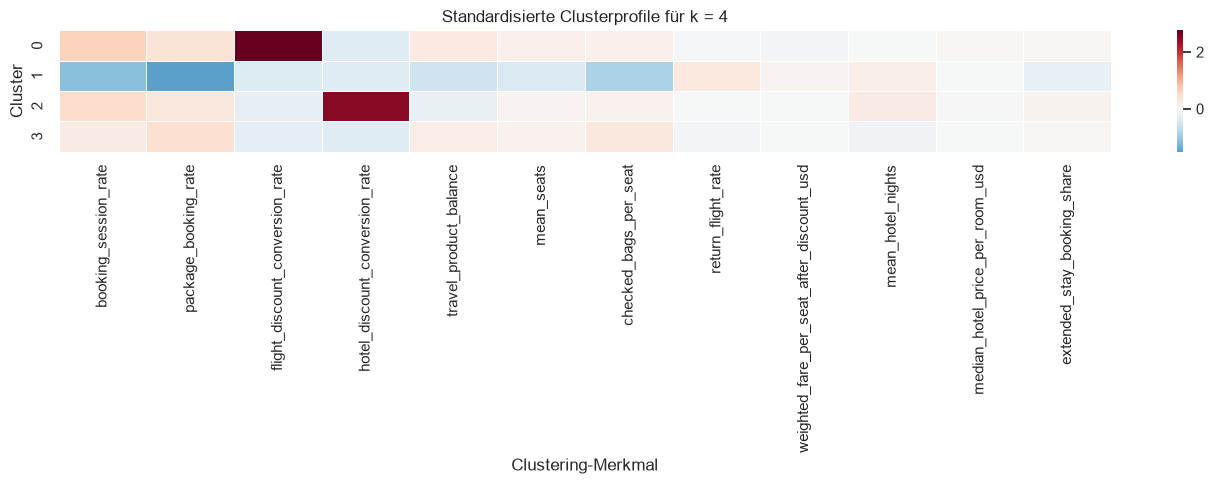

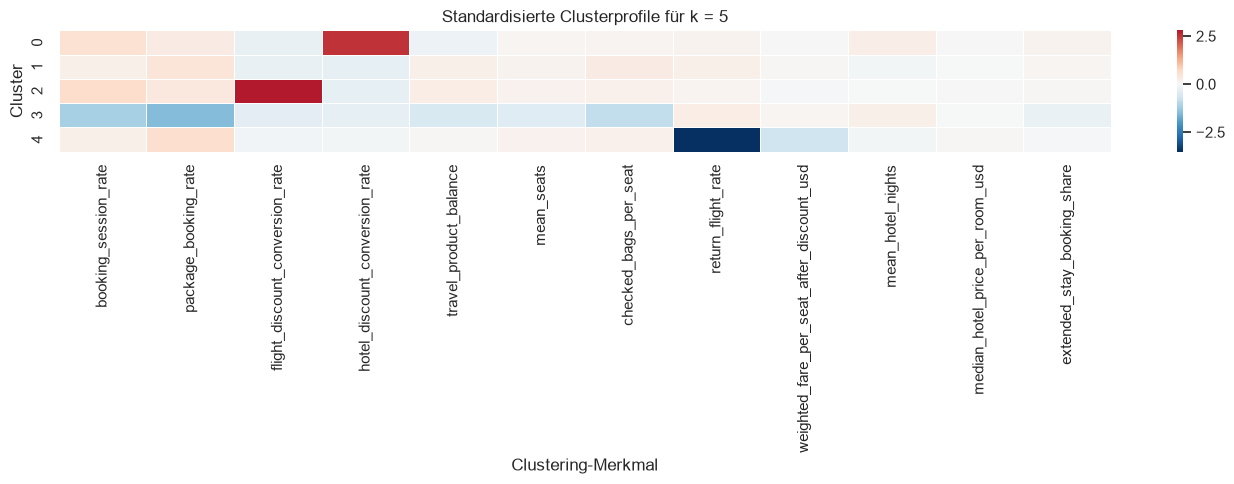

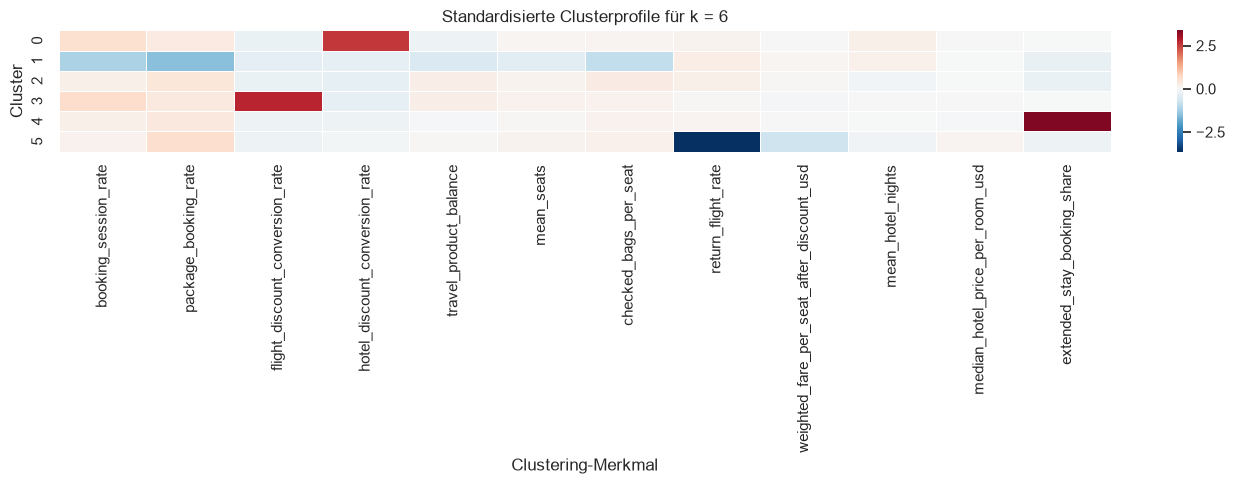

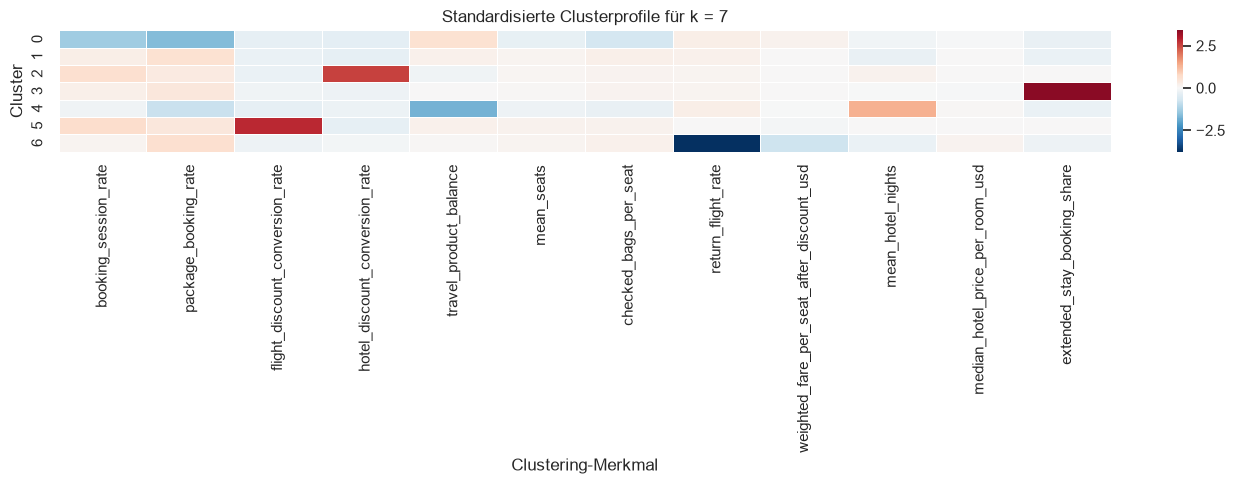

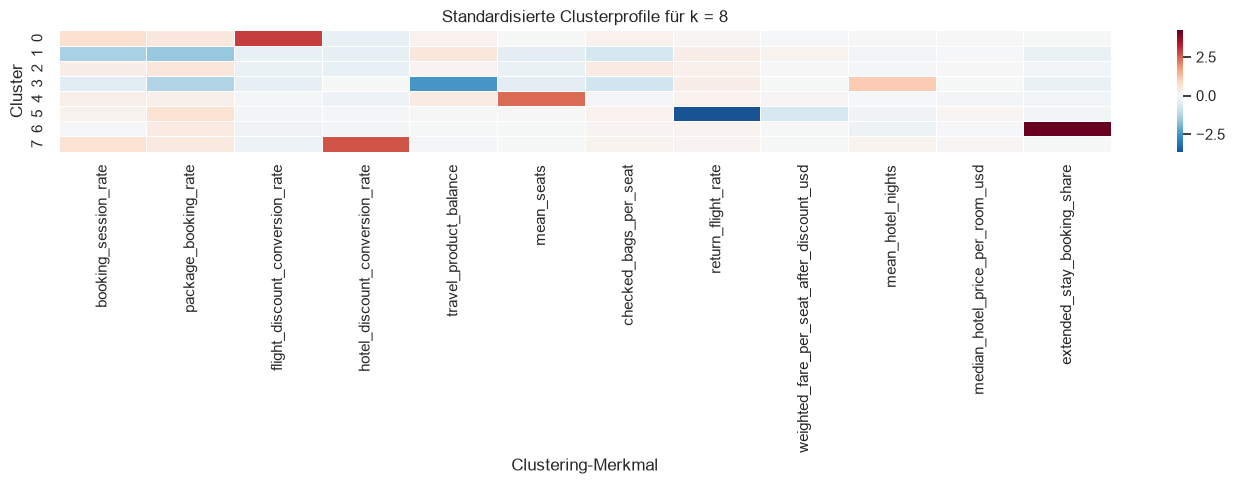

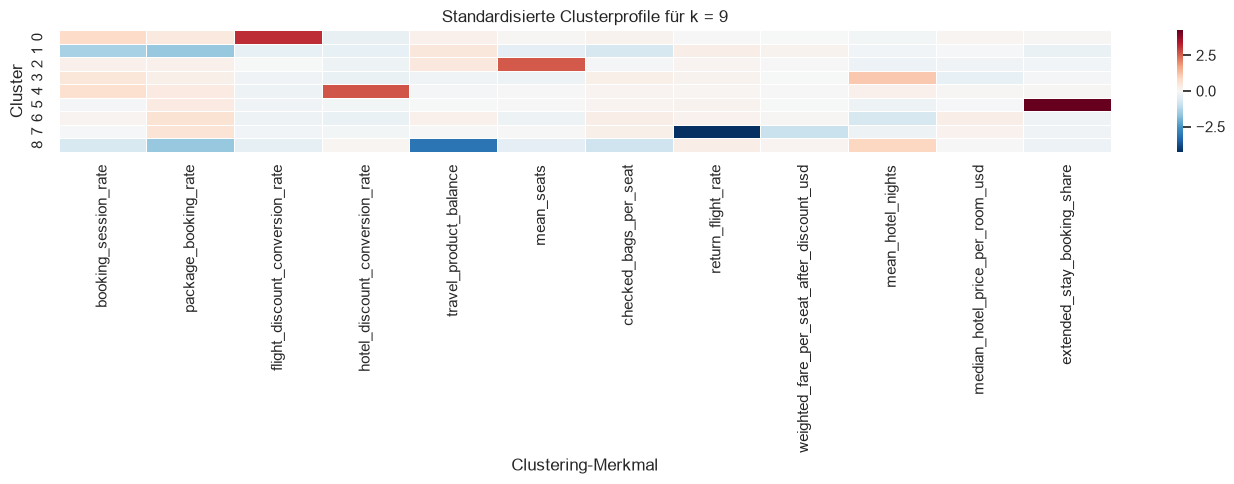

In [ ]:
# Standardisierte Clusterprofile visualisieren.

for k in candidate_k_values:
    
    plt.figure(figsize=(14, 5))
    
    sns.heatmap(
        candidate_cluster_profiles[k],
        cmap="RdBu_r",
        center=0,
        annot=False,
        linewidths=0.5
    )
    
    plt.title(
        f"Standardisierte Clusterprofile für k = {k}"
    )
    
    plt.xlabel("Clustering-Merkmal")
    plt.ylabel("Cluster")
    
    plt.tight_layout()
    plt.show()

### Auswahl der Clusteranzahl

Zur Auswahl einer geeigneten Clusteranzahl wurden Lösungen mit vier bis neun
Clustern hinsichtlich Silhouette Score, Clustergrößen, Stabilität und
inhaltlicher Interpretierbarkeit verglichen.

Der Silhouette Score stieg mit zunehmender Clusteranzahl an und erreichte bei
neun Clustern den höchsten Wert. Die Verbesserung gegenüber kompakteren
Lösungen war jedoch vergleichsweise gering. Gleichzeitig hätten sieben bis
neun zusätzliche Cluster zusammen mit den sechs regelbasierten Segmenten zu
einer sehr kleinteiligen und operativ schwer handhabbaren
Kundensegmentierung geführt.

Die Lösung mit vier Clustern weist mit einem durchschnittlichen Adjusted Rand
Index von 0,975 eine sehr hohe Stabilität auf. Außerdem entstehen vier
grundsätzlich unterscheidbare Verhaltensmuster, ohne bereits regelbasiert
abgebildete Kundengruppen unnötig weiter zu unterteilen.

Aus diesem Grund wird für die bislang nicht zugeordneten Kunden eine
K-Means-Lösung mit vier Clustern gewählt. Damit umfasst die kombinierte
Segmentierung insgesamt sechs regelbasierte und vier datenbasierte
Kundengruppen.

In [54]:
# Finales K-Means-Modell berechnen

final_k = 4

final_kmeans_model = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

final_kmeans_labels = final_kmeans_model.fit_predict(
    x_cluster_scaled
)

In [56]:
# Clusterzuordnung ergänzen

unassigned_clustered = unassigned_customers.loc[
    x_cluster.index
].copy()

unassigned_clustered["kmeans_cluster"] = (
    final_kmeans_labels
)

print(
    "Kunden in der Clustertabelle:",
    len(unassigned_clustered)
)

print(
    "Fehlende Clusterzuordnungen:",
    unassigned_clustered["kmeans_cluster"].isna().sum()
)

display(
    unassigned_clustered["kmeans_cluster"]
    .value_counts()
    .sort_index()
)

Kunden in der Clustertabelle: 2817
Fehlende Clusterzuordnungen: 0


kmeans_cluster
0     263
1     607
2     330
3    1617
Name: count, dtype: int64

In [58]:
# Clusterprofile in den ursprünglichen Einheiten anzeigen.

cluster_profile_data = x_cluster.copy()

cluster_profile_data["kmeans_cluster"] = (
    final_kmeans_labels
)


cluster_profiles_original = (
    cluster_profile_data
    .groupby("kmeans_cluster")
    .mean()
    .round(3)
)

display(cluster_profiles_original)

,booking_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,travel_product_balance,mean_seats,checked_bags_per_seat,return_flight_rate,weighted_fare_per_seat_after_discount_usd,mean_hotel_nights,median_hotel_price_per_room_usd,extended_stay_booking_share
kmeans_cluster,,,,,,,,,,,,
0,0.384,0.789,0.746,0.013,0.050,1.161,0.400,0.954,339.387,2.872,163.125,0.050
1,0.065,0.050,0.003,0.012,-0.199,1.000,0.002,1.000,344.834,3.138,154.553,0.009
2,0.366,0.760,0.034,0.726,-0.086,1.141,0.383,0.958,350.016,3.197,164.217,0.060
3,0.312,0.817,0.030,0.010,0.038,1.152,0.447,0.950,363.895,2.727,165.448,0.054


In [59]:
# Mediane der Cluster berechnen.

cluster_profiles_median = (
    cluster_profile_data
    .groupby("kmeans_cluster")
    .median()
    .round(3)
)

display(cluster_profiles_median)

,booking_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,travel_product_balance,mean_seats,checked_bags_per_seat,return_flight_rate,weighted_fare_per_seat_after_discount_usd,mean_hotel_nights,median_hotel_price_per_room_usd,extended_stay_booking_share
kmeans_cluster,,,,,,,,,,,,
0,0.375,1.000,0.667,0.000,0.000,1.000,0.333,1.000,310.215,2.500,147.000,0.000
1,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,334.279,2.667,147.000,0.000
2,0.375,0.750,0.000,0.500,0.000,1.000,0.333,1.000,334.279,3.000,143.250,0.000
3,0.250,1.000,0.000,0.000,0.000,1.000,0.500,1.000,341.640,2.500,147.000,0.000


In [60]:
# Kompakte Größenübersicht der Cluster erstellen.

final_cluster_sizes = (
    unassigned_clustered
    .groupby("kmeans_cluster")
    .size()
    .rename("customer_count")
    .to_frame()
)

final_cluster_sizes["customer_share"] = (
    final_cluster_sizes["customer_count"]
    / final_cluster_sizes["customer_count"].sum()
)

display(final_cluster_sizes)

,customer_count,customer_share
kmeans_cluster,,
0,263,0.093
1,607,0.215
2,330,0.117
3,1617,0.574


In [61]:
# Ergänzung von Segmentbezeichnungen für die K-Means-Cluster.

kmeans_segment_mapping = {
    0: "Flight Deal Travelers",
    1: "Low-Conversion Browsers",
    2: "Hotel Deal Travelers",
    3: "Regular Package Travelers"
}

unassigned_clustered["segment"] = (
    unassigned_clustered["kmeans_cluster"]
    .map(kmeans_segment_mapping)
)

display(
    unassigned_clustered[
        ["user_id", "kmeans_cluster", "segment"]
    ].head()
)

,user_id,kmeans_cluster,segment
0,94883,3,Regular Package Travelers
1,101486,1,Low-Conversion Browsers
2,101961,0,Flight Deal Travelers
3,133058,1,Low-Conversion Browsers
4,152583,3,Regular Package Travelers


### Interpretation der K-Means-Cluster

Die Lösung mit vier Clustern unterteilt die bislang nicht zugeordneten Kunden
in vier verständliche Verhaltensgruppen.

Die **Flight Deal Travelers** reagieren besonders häufig auf angebotene
Flugrabatte und buchen überwiegend kombinierte Reisepakete. Die
**Hotel Deal Travelers** weisen dagegen eine besonders hohe Nutzung von
Hotelrabatten auf.

Die **Low-Conversion Browsers** zeigen trotz vorhandener Sessions bislang nur
eine geringe Buchungsaktivität. Da für viele dieser Kunden keine Flug- oder
Hotelbuchungen vorliegen, beruhen einige produktspezifische Werte auf der
Median-Imputation und werden nicht zur inhaltlichen Beschreibung der Gruppe
herangezogen.

Die **Regular Package Travelers** bilden die größte datenbasierte Gruppe. Sie
buchen häufig Flug und Hotel gemeinsam, reagieren jedoch kaum auf bisherige
Rabattangebote und weisen ansonsten ein vergleichsweise durchschnittliches
Reiseverhalten auf.

Die datenbasierten Cluster ergänzen damit die zuvor regelbasiert definierten
Segmente. Während die regelbasierten Gruppen besonders ausgeprägte
Reisebedürfnisse abbilden, differenziert K-Means die verbleibenden Kunden vor
allem anhand ihrer Buchungsaktivität und ihrer Reaktion auf Flug- und
Hotelrabatte.

### Ergänzende Profilierung der K-Means-Cluster

Zur inhaltlichen Beschreibung der K-Means-Cluster werden ergänzende Merkmale
herangezogen, die nicht in die Clusterbildung eingeflossen sind. Dazu gehören
insbesondere demografische Eigenschaften, absolute Buchungszahlen und der
historische Kundenwert.

Diese Merkmale verändern die Clusterzuordnung nicht. Sie dienen ausschließlich
dazu, die gefundenen Gruppen besser zu verstehen und später geeignete
Marketingmaßnahmen und Rewards-Benefits abzuleiten.

Die bisherigen Segmentbezeichnungen werden zunächst als Arbeitsnamen
verwendet. Die endgültige Benennung erfolgt nach dem Vergleich mit DBSCAN
und der Visualisierung mittels PCA.

In [62]:
# Verfügbare Profilmerkmale bestimmen.

profiling_candidates = [
    # Demografie
    "age",
    "has_children",
    "married",

    # Kundenaktivität
    "session_count",
    "booking_session_count",
    "flight_booking_count",
    "hotel_booking_count",

    # Absolute Reiseaktivität
    "total_seats",
    "total_checked_bags",
    "total_hotel_nights",
    "total_rooms",

    # Ausgaben und Kundenwert
    "total_flight_spend_before_discount_usd",
    "total_flight_spend_after_discount_usd",
    "total_hotel_spend_usd",
    "historical_customer_value_usd"
]

available_profiling_columns = [
    column
    for column in profiling_candidates
    if column in unassigned_clustered.columns
]

missing_profiling_columns = [
    column
    for column in profiling_candidates
    if column not in unassigned_clustered.columns
]

print("Verfügbare Profilmerkmale:")
print(available_profiling_columns)

print("\nNicht vorhandene Kandidaten:")
print(missing_profiling_columns)

Verfügbare Profilmerkmale:
['age', 'has_children', 'married', 'session_count', 'booking_session_count', 'flight_booking_count', 'hotel_booking_count', 'total_seats', 'total_checked_bags', 'total_hotel_nights', 'total_rooms', 'historical_customer_value_usd']

Nicht vorhandene Kandidaten:
['total_flight_spend_before_discount_usd', 'total_flight_spend_after_discount_usd', 'total_hotel_spend_usd']


In [63]:
# Mittelwerte nach Clustern berechnen.

cluster_profile_means_extended = (
    unassigned_clustered
    .groupby(
        ["kmeans_cluster", "segment"]
    )[available_profiling_columns]
    .mean()
    .round(2)
)

display(cluster_profile_means_extended)

,,age,has_children,married,session_count,booking_session_count,flight_booking_count,hotel_booking_count,total_seats,total_checked_bags,total_hotel_nights,total_rooms,historical_customer_value_usd
kmeans_cluster,segment,,,,,,,,,,,,
0,Flight Deal Travelers,41.810,0.310,0.430,8.160,3.140,2.890,2.740,3.360,1.250,8.160,3.170,"2,605.700"
1,Low-Conversion Browsers,41.520,0.370,0.490,8.190,0.540,0.160,0.480,0.160,0.000,2.000,0.600,476.420
2,Hotel Deal Travelers,41.920,0.300,0.470,8.210,3.000,2.500,2.780,2.880,1.100,8.900,3.250,"2,607.050"
3,Regular Package Travelers,41.700,0.320,0.450,8.210,2.550,2.340,2.260,2.700,1.070,6.410,2.610,"2,144.170"


In [64]:
# Mediane nach Cluster berechnen.

cluster_profile_medians_extended = (
    unassigned_clustered
    .groupby(
        ["kmeans_cluster", "segment"]
    )[available_profiling_columns]
    .median()
    .round(2)
)

display(cluster_profile_medians_extended)

,,age,has_children,married,session_count,booking_session_count,flight_booking_count,hotel_booking_count,total_seats,total_checked_bags,total_hotel_nights,total_rooms,historical_customer_value_usd
kmeans_cluster,segment,,,,,,,,,,,,
0,Flight Deal Travelers,42.000,0.000,0.000,8.000,3.000,3.000,3.000,3.000,1.000,7.000,3.000,"2,445.700"
1,Low-Conversion Browsers,37.000,0.000,0.000,8.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,Hotel Deal Travelers,42.000,0.000,0.000,8.000,3.000,2.000,3.000,3.000,1.000,8.000,3.000,"2,387.360"
3,Regular Package Travelers,42.000,0.000,0.000,8.000,2.000,2.000,2.000,3.000,1.000,5.000,2.000,"1,877.460"


In [65]:
# Demografische Anteile gesondert darstellen.

demographic_share_columns = [
    column
    for column in [
        "has_children",
        "married"
    ]
    if column in unassigned_clustered.columns
]

if demographic_share_columns:
    
    cluster_demographic_shares = (
        unassigned_clustered
        .groupby(
            ["kmeans_cluster", "segment"]
        )[demographic_share_columns]
        .mean()
        .mul(100)
        .round(1)
    )
    
    cluster_demographic_shares.columns = [
        f"{column}_share_percent"
        for column in cluster_demographic_shares.columns
    ]
    
    display(cluster_demographic_shares)

,,has_children_share_percent,married_share_percent
kmeans_cluster,segment,,
0,Flight Deal Travelers,31.200,42.600
1,Low-Conversion Browsers,37.100,48.600
2,Hotel Deal Travelers,30.300,47.300
3,Regular Package Travelers,31.800,45.100


In [66]:
# Geschlechterverteilung prüfen.

if "gender" in unassigned_clustered.columns:
    
    cluster_gender_distribution = (
        pd.crosstab(
            unassigned_clustered["segment"],
            unassigned_clustered["gender"],
            normalize="index"
        )
        .mul(100)
        .round(1)
    )
    
    display(cluster_gender_distribution)

gender,F,M,O
segment,,,
Flight Deal Travelers,87.800,12.200,0.000
Hotel Deal Travelers,86.700,12.700,0.600
Low-Conversion Browsers,87.300,12.500,0.200
Regular Package Travelers,88.400,11.400,0.200


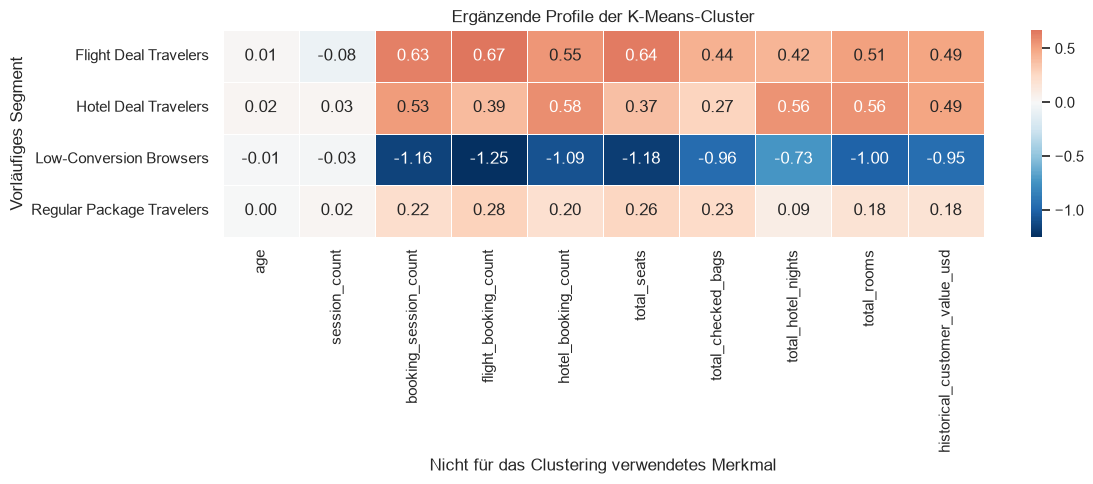

In [67]:
# Abweichungen vom Durchschnitt visualisieren.

numeric_profile_columns = [
    column
    for column in available_profiling_columns
    if pd.api.types.is_numeric_dtype(
        unassigned_clustered[column]
    )
    and column not in ["has_children", "married"]
]


cluster_profile_for_heatmap = (
    unassigned_clustered
    .groupby("segment")[numeric_profile_columns]
    .mean()
)


overall_means = (
    unassigned_clustered[numeric_profile_columns]
    .mean()
)

overall_std = (
    unassigned_clustered[numeric_profile_columns]
    .std()
    .replace(0, np.nan)
)


cluster_profile_deviation = (
    cluster_profile_for_heatmap - overall_means
) / overall_std


plt.figure(
    figsize=(
        max(12, len(numeric_profile_columns) * 1.1),
        5
    )
)

sns.heatmap(
    cluster_profile_deviation,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Ergänzende Profile der K-Means-Cluster"
)
plt.xlabel("Nicht für das Clustering verwendetes Merkmal")
plt.ylabel("Vorläufiges Segment")

plt.tight_layout()
plt.show()

### Ergebnis der ergänzenden Clusterprofilierung

Die ergänzende Profilierung bestätigt die anhand der Clustering-Merkmale
abgeleiteten Arbeitsnamen.

Die **Flight Deal Travelers** weisen eine hohe Flugaktivität, die meisten
Flugbuchungen und eine ausgeprägte Nutzung von Flugrabatten auf. Die
**Hotel Deal Travelers** besitzen dagegen eine hohe Hotelaktivität, buchen
vergleichsweise viele Hotelnächte und reagieren besonders häufig auf
Hotelrabatte. Beide Gruppen weisen innerhalb der datenbasiert segmentierten
Kunden einen überdurchschnittlichen historischen Kundenwert auf.

Die **Low-Conversion Browsers** verfügen über eine ähnliche Anzahl an
Sessions wie die übrigen Kunden, schließen jedoch deutlich seltener eine
Buchung ab. Ihr medianer historischer Kundenwert liegt bei null. Die
**Regular Package Travelers** zeigen hingegen eine regelmäßige Flug- und
Hotelaktivität und buchen häufig kombinierte Reisepakete, ohne besonders
stark auf bisherige Rabattangebote zu reagieren.

Alter, Kinderanteil, Familienstand und Geschlechterverteilung unterscheiden
sich zwischen den vier Gruppen nur geringfügig. Die datenbasierten Cluster
werden somit vor allem durch das tatsächliche Buchungs- und Reiseverhalten
und nicht durch demografische Merkmale charakterisiert.

Die Segmentnamen werden bis zum Vergleich mit DBSCAN und zur
PCA-Visualisierung weiterhin als Arbeitsnamen behandelt.

## 6. DBSCAN als Vergleichsverfahren

DBSCAN wird als alternatives Clustering-Verfahren eingesetzt, um zu prüfen,
ob sich in den nicht regelbasiert zugeordneten Kunden natürliche
Dichtebereiche erkennen lassen.

Im Gegensatz zu K-Means muss bei DBSCAN die Anzahl der Cluster nicht vorab
festgelegt werden. Das Verfahren gruppiert eng beieinanderliegende Kunden
und kennzeichnet Kunden außerhalb ausreichend dichter Bereiche als
Rauschpunkte beziehungsweise Ausreißer.

Die beiden zentralen Parameter sind:

- `eps`: maximaler Abstand zwischen benachbarten Datenpunkten,
- `min_samples`: Mindestanzahl an Datenpunkten innerhalb eines dichten
  Bereichs.

DBSCAN wird auf denselben transformierten und standardisierten Merkmalen wie
K-Means durchgeführt. Das Ergebnis dient zunächst als methodischer Vergleich
und ersetzt nicht automatisch die zuvor ausgewählte K-Means-Lösung.

In [69]:
# Ausgangswert für min_samples
 
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score


number_of_features = x_cluster_scaled.shape[1]

min_samples_initial = 2 * number_of_features

print("Anzahl der Merkmale:", number_of_features)
print("Ausgangswert für min_samples:", min_samples_initial)

Anzahl der Merkmale: 12
Ausgangswert für min_samples: 24


In [70]:
# K-Distanz berechnen.

nearest_neighbors = NearestNeighbors(
    n_neighbors=min_samples_initial
)

nearest_neighbors.fit(x_cluster_scaled)

neighbor_distances, neighbor_indices = (
    nearest_neighbors.kneighbors(x_cluster_scaled)
)


k_distances = np.sort(
    neighbor_distances[:, -1]
)

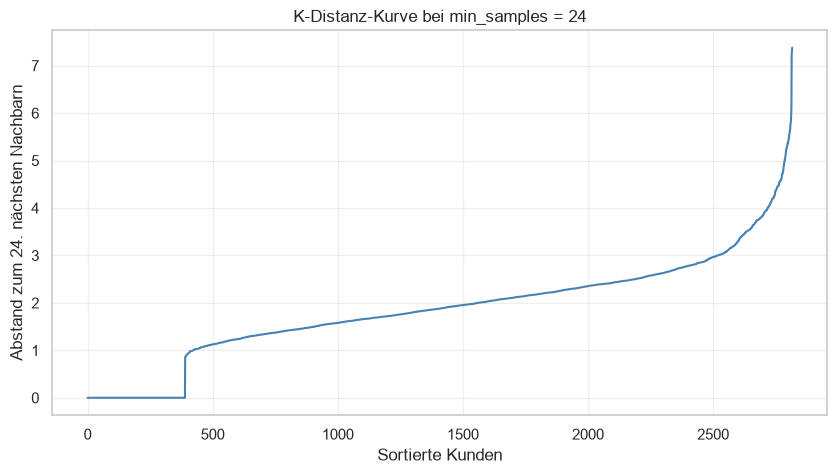

In [71]:
# K-Distanz-Kurve darstellen.

plt.figure(figsize=(10, 5))

plt.plot(
    k_distances,
    color="steelblue"
)

plt.title(
    f"K-Distanz-Kurve bei min_samples = {min_samples_initial}"
)
plt.xlabel("Sortierte Kunden")
plt.ylabel(
    f"Abstand zum {min_samples_initial}. nächsten Nachbarn"
)

plt.grid(alpha=0.3)
plt.show()

In [72]:
# Quantile der K-Distanzen prüfen.

distance_quantiles = (
    pd.Series(k_distances)
    .quantile([
        0.80,
        0.85,
        0.90,
        0.92,
        0.94,
        0.95,
        0.96,
        0.97,
        0.98,
        0.99
    ])
    .rename("eps_candidate")
    .to_frame()
)

display(distance_quantiles)

,eps_candidate
0.800,2.581
0.850,2.770
0.900,3.028
0.920,3.242
0.940,3.551
0.950,3.742
0.960,3.891
0.970,4.128
0.980,4.462
0.990,5.044


In [74]:
# Erste DBSCAN-Parameter testen

eps_candidates = np.unique(
    np.round(
        distance_quantiles["eps_candidate"].to_numpy(),
        3
    )
)

dbscan_results = []


for eps in eps_candidates:
    
    dbscan_model = DBSCAN(
        eps=eps,
        min_samples=min_samples_initial
    )
    
    dbscan_labels = dbscan_model.fit_predict(
        x_cluster_scaled
    )
    
    non_noise_mask = dbscan_labels != -1
    
    cluster_labels_without_noise = (
        dbscan_labels[non_noise_mask]
    )
    
    unique_clusters = set(dbscan_labels)
    unique_clusters.discard(-1)
    
    number_of_clusters = len(unique_clusters)
    number_of_noise_points = (~non_noise_mask).sum()
    noise_share = (
        number_of_noise_points / len(dbscan_labels)
    )
    
    if number_of_clusters >= 2:
        
        silhouette = silhouette_score(
            x_cluster_scaled.loc[non_noise_mask],
            cluster_labels_without_noise
        )
        
        cluster_sizes = (
            pd.Series(cluster_labels_without_noise)
            .value_counts()
        )
        
        smallest_cluster_size = cluster_sizes.min()
        largest_cluster_size = cluster_sizes.max()
    
    else:
        silhouette = np.nan
        smallest_cluster_size = np.nan
        largest_cluster_size = np.nan
    
    dbscan_results.append({
        "eps": eps,
        "min_samples": min_samples_initial,
        "number_of_clusters": number_of_clusters,
        "noise_count": number_of_noise_points,
        "noise_share": noise_share,
        "silhouette_without_noise": silhouette,
        "smallest_cluster_size": smallest_cluster_size,
        "largest_cluster_size": largest_cluster_size
    })


dbscan_evaluation = pd.DataFrame(dbscan_results)

display(dbscan_evaluation)

,eps,min_samples,number_of_clusters,noise_count,noise_share,silhouette_without_noise,smallest_cluster_size,largest_cluster_size
0,2.581,24,1,202,0.072,NaN,NaN,NaN
1,2.770,24,1,154,0.055,NaN,NaN,NaN
2,3.028,24,1,119,0.042,NaN,NaN,NaN
3,3.242,24,1,96,0.034,NaN,NaN,NaN
4,3.551,24,1,61,0.022,NaN,NaN,NaN
5,3.742,24,1,34,0.012,NaN,NaN,NaN
6,3.891,24,1,20,0.007,NaN,NaN,NaN
7,4.128,24,1,8,0.003,NaN,NaN,NaN
8,4.462,24,1,4,0.001,NaN,NaN,NaN
9,5.044,24,1,1,0.000,NaN,NaN,NaN


In [76]:
# Erweiterter Parametertest
 
eps_values_extended = [
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    1.75,
    2.00,
    2.25,
    2.50
]

min_samples_values = [
    5,
    10,
    15,
    24,
    36
]

dbscan_extended_results = []


for min_samples in min_samples_values:
    
    for eps in eps_values_extended:
        
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
        
        labels = model.fit_predict(
            x_cluster_scaled
        )
        
        non_noise_mask = labels != -1
        non_noise_labels = labels[non_noise_mask]
        
        unique_clusters = set(labels)
        unique_clusters.discard(-1)
        
        number_of_clusters = len(unique_clusters)
        noise_count = (~non_noise_mask).sum()
        noise_share = noise_count / len(labels)
        
        if number_of_clusters >= 1:
            
            cluster_sizes = (
                pd.Series(non_noise_labels)
                .value_counts()
            )
            
            smallest_cluster_size = (
                cluster_sizes.min()
            )
            
            largest_cluster_size = (
                cluster_sizes.max()
            )
            
            largest_cluster_share = (
                largest_cluster_size / len(labels)
            )
            
        else:
            smallest_cluster_size = np.nan
            largest_cluster_size = np.nan
            largest_cluster_share = np.nan
        
        
        if (
            number_of_clusters >= 2
            and len(non_noise_labels) > number_of_clusters
        ):
            
            silhouette = silhouette_score(
                x_cluster_scaled.loc[non_noise_mask],
                non_noise_labels
            )
            
        else:
            silhouette = np.nan
        
        
        dbscan_extended_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "number_of_clusters": number_of_clusters,
            "noise_count": noise_count,
            "noise_share": noise_share,
            "silhouette_without_noise": silhouette,
            "smallest_cluster_size": smallest_cluster_size,
            "largest_cluster_size": largest_cluster_size,
            "largest_cluster_share": largest_cluster_share
        })


dbscan_extended_evaluation = pd.DataFrame(
    dbscan_extended_results
)

display(dbscan_extended_evaluation)

,eps,min_samples,number_of_clusters,noise_count,noise_share,silhouette_without_noise,smallest_cluster_size,largest_cluster_size,largest_cluster_share
0,0.500,5,19,2273,0.807,0.863,3,390,0.138
1,0.750,5,16,2075,0.737,0.667,5,390,0.138
2,1.000,5,19,1629,0.578,0.361,5,449,0.159
3,1.250,5,21,1217,0.432,0.298,4,817,0.290
4,1.500,5,18,844,0.300,0.245,5,1182,0.420
5,1.750,5,11,522,0.185,0.105,5,1945,0.690
6,2.000,5,9,286,0.102,0.087,5,2304,0.818
7,2.250,5,5,176,0.062,0.228,9,2591,0.920
8,2.500,5,5,106,0.038,0.231,9,2647,0.940
9,0.500,10,2,2416,0.858,0.997,11,390,0.138


In [77]:
# Potenziell brauchbare Lösungen filtern.

plausible_dbscan_solutions = (
    dbscan_extended_evaluation
    .loc[
        (
            dbscan_extended_evaluation[
                "number_of_clusters"
            ] >= 2
        )
        & (
            dbscan_extended_evaluation[
                "noise_share"
            ] <= 0.40
        )
        & (
            dbscan_extended_evaluation[
                "smallest_cluster_size"
            ] >= 30
        )
    ]
    .sort_values(
        [
            "silhouette_without_noise",
            "noise_share"
        ],
        ascending=[False, True]
    )
)

display(plausible_dbscan_solutions)

,eps,min_samples,number_of_clusters,noise_count,noise_share,silhouette_without_noise,smallest_cluster_size,largest_cluster_size,largest_cluster_share
32,1.750,24,4,1021,0.362,0.272,31,1607,0.570
42,2.000,36,4,782,0.278,0.249,36,1831,0.650
14,1.750,10,5,682,0.242,0.245,50,1853,0.658
33,2.000,24,5,631,0.224,0.231,42,1914,0.679
24,2.000,15,4,489,0.174,0.230,51,2079,0.738
15,2.000,10,3,425,0.151,0.225,52,2224,0.789


In [78]:
# Alle Mehrcluster-Lösungen kontrollieren

multi_cluster_dbscan_solutions = (
    dbscan_extended_evaluation
    .loc[
        dbscan_extended_evaluation[
            "number_of_clusters"
        ] >= 2
    ]
    .sort_values(
        [
            "noise_share",
            "smallest_cluster_size"
        ],
        ascending=[True, False]
    )
)

display(multi_cluster_dbscan_solutions)

,eps,min_samples,number_of_clusters,noise_count,noise_share,silhouette_without_noise,smallest_cluster_size,largest_cluster_size,largest_cluster_share
8,2.500,5,5,106,0.038,0.231,9,2647,0.940
17,2.500,10,3,165,0.059,0.249,10,2629,0.933
7,2.250,5,5,176,0.062,0.228,9,2591,0.920
6,2.000,5,9,286,0.102,0.087,5,2304,0.818
15,2.000,10,3,425,0.151,0.225,52,2224,0.789
24,2.000,15,4,489,0.174,0.230,51,2079,0.738
5,1.750,5,11,522,0.185,0.105,5,1945,0.690
33,2.000,24,5,631,0.224,0.231,42,1914,0.679
14,1.750,10,5,682,0.242,0.245,50,1853,0.658
42,2.000,36,4,782,0.278,0.249,36,1831,0.650


In [79]:
# Repräsentatives DBSCAN-Modell speichern

dbscan_comparison_model = DBSCAN(
    eps=2.0,
    min_samples=15
)

dbscan_comparison_labels = (
    dbscan_comparison_model
    .fit_predict(x_cluster_scaled)
)

print(
    "DBSCAN-Cluster einschließlich Rauschen:"
)

display(
    pd.Series(dbscan_comparison_labels)
    .value_counts()
    .sort_index()
)

print(
    "Rauschanteil:",
    round(
        (dbscan_comparison_labels == -1).mean(),
        3
    )
)

DBSCAN-Cluster einschließlich Rauschen:


-1     489
 0    2079
 1      51
 2      82
 3     116
Name: count, dtype: int64

Rauschanteil: 0.174


### Ergebnis des DBSCAN-Clusterings

DBSCAN wurde mit unterschiedlichen Werten für `eps` und `min_samples`
untersucht. Bei den zunächst aus der K-Distanz-Kurve abgeleiteten
Parameterwerten entstand jeweils nur ein zusammenhängendes Cluster.

Bei kleineren Distanzschwellen konnten mehrere Cluster identifiziert werden.
Diese Lösungen waren jedoch mit einem erheblichen Anteil an Rauschpunkten,
sehr kleinen Einzelclustern oder einem stark dominierenden Hauptcluster
verbunden. Hohe Silhouette Scores traten insbesondere bei Lösungen auf, bei
denen ein großer Teil der Kunden als Rauschen ausgeschlossen wurde.

Auch die vergleichsweise praktikable Einstellung mit `eps = 2.0` und
`min_samples = 15` ordnete rund 17 % der Kunden keinem Cluster zu. Gleichzeitig
umfasste das größte Cluster etwa 74 % aller betrachteten Kunden.

Die Ergebnisse deuten darauf hin, dass die Kundenprofile keine klar
voneinander getrennten dichtebasierten Gruppen bilden. Das Reise- und
Buchungsverhalten scheint vielmehr durch kontinuierliche Übergänge und
einzelne ungewöhnliche Profile geprägt zu sein.

DBSCAN wird daher nicht für die finale Kundensegmentierung verwendet.
K-Means ist für das operative Ziel geeigneter, da es alle Kunden einer
stabilen und verständlichen Gruppe zuordnet. Die ausgewählte
DBSCAN-Konfiguration wird lediglich für den anschließenden visuellen Vergleich
mittels PCA beibehalten.